<b>Business Objective:<b>

For every customer, rank the brands they have not yet purchased based on their likelihood of adopting them in the next campaign window.

This is not a homepage recommendation problem.

This is a cross-brand expansion / multi-brand targeting problem.

In [1747]:
import os 
import pandas as pd
import numpy as np

from lightgbm import LGBMRanker, plot_importance
from lightgbm import early_stopping, log_evaluation

import mlflow
import pickle

# Ignore

In [1552]:
path = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "data\\cross-brand expansion\\realistic_cross_brand_ranking_dataset.xlsx")) 
path

'C:\\git\\ML-hands-on-notebooks\\data\\cross-brand expansion\\realistic_cross_brand_ranking_dataset.xlsx'

In [1553]:
df = pd.read_excel(path, header=0)
df.head()

,customer_id,feature_cutoff_date,candidate_brand,age,gender,income,city_tier,rfm_score,frequency_6m,avg_spend,...,categories_bought,brands_purchased_before_cutoff,num_brands_purchased,brand_price_segment,brand_style,brand_target_age,brand_popularity,season,campaign_type,label_future_purchase
0,100001,2025-06-30,Brand_B,38,M,128500,3,0.24,18,2342,...,"Formal,Luxury",Brand_A,1,Premium,Formal,30-45,0.84,Monsoon,Email,0
1,100001,2025-06-30,Brand_C,38,M,128500,3,0.24,18,2342,...,"Formal,Luxury",Brand_A,1,Mid,Sports,20-35,0.66,Monsoon,Email,1
2,100001,2025-06-30,Brand_D,38,M,128500,3,0.24,18,2342,...,"Formal,Luxury",Brand_A,1,Premium,Ethnic,25-40,0.81,Monsoon,Email,0
3,100001,2025-06-30,Brand_E,38,M,128500,3,0.24,18,2342,...,"Formal,Luxury",Brand_A,1,Budget,Sports,18-30,0.58,Monsoon,Email,0
4,100001,2025-06-30,Brand_F,38,M,128500,3,0.24,18,2342,...,"Formal,Luxury",Brand_A,1,Mid,Casual,25-35,0.63,Monsoon,Email,0


In [1554]:
df.shape

(39894, 23)

In [1555]:
df.columns

Index(['customer_id', 'feature_cutoff_date', 'candidate_brand', 'age',
       'gender', 'income', 'city_tier', 'rfm_score', 'frequency_6m',
       'avg_spend', 'discount_pct', 'return_rate', 'recency_days',
       'categories_bought', 'brands_purchased_before_cutoff',
       'num_brands_purchased', 'brand_price_segment', 'brand_style',
       'brand_target_age', 'brand_popularity', 'season', 'campaign_type',
       'label_future_purchase'],
      dtype='object')

In [1556]:
df.describe()

,customer_id,age,income,city_tier,rfm_score,frequency_6m,avg_spend,discount_pct,return_rate,recency_days,num_brands_purchased,brand_popularity,label_future_purchase
count,39894.000000,39894.000000,39894.000000,39894.000000,39894.000000,39894.000000,39894.000000,39894.000000,39894.000000,39894.000000,39894.000000,39894.000000,39894.000000
mean,102501.762947,38.989297,137509.127312,1.994285,0.599875,10.448940,7796.899358,25.078533,0.124724,91.035519,1.937685,0.699858,0.150800
std,1443.984372,12.367513,65296.561262,0.819826,0.230693,5.736704,4095.572748,14.511949,0.072352,51.530666,0.813663,0.092424,0.357858
min,100001.000000,18.000000,25000.000000,1.000000,0.200000,1.000000,805.000000,0.000000,0.000000,1.000000,1.000000,0.550000,0.000000
25%,101250.000000,28.000000,81540.000000,1.000000,0.400000,6.000000,4250.000000,13.000000,0.060000,48.000000,1.000000,0.630000,0.000000
50%,102504.000000,39.000000,137550.000000,2.000000,0.600000,10.000000,7766.000000,25.000000,0.120000,92.000000,2.000000,0.680000,0.000000
75%,103752.000000,50.000000,194441.000000,3.000000,0.800000,15.000000,11334.000000,38.000000,0.190000,136.000000,3.000000,0.790000,0.000000
max,105000.000000,60.000000,249921.000000,3.000000,1.000000,20.000000,15000.000000,50.000000,0.250000,180.000000,3.000000,0.840000,1.000000


In [1557]:
df.describe(include=['O'])

,feature_cutoff_date,candidate_brand,gender,categories_bought,brands_purchased_before_cutoff,brand_price_segment,brand_style,brand_target_age,season,campaign_type
count,39894,39894,39894,39894,39894,39894,39894,39894,39894,39894
unique,1,10,2,80,764,4,5,8,4,4
top,2025-06-30,Brand_H,M,"Formal,Ethnic",Brand_D,Mid,Casual,20-35,Monsoon,Push
freq,39894,4075,20182,1125,1728,12019,11905,7969,10473,10172


In [1558]:
df["brands_purchased_before_cutoff"].tail(10)

39884    Brand_F,Brand_I,Brand_C
39885    Brand_F,Brand_I,Brand_C
39886    Brand_F,Brand_I,Brand_C
39887    Brand_G,Brand_D,Brand_I
39888    Brand_G,Brand_D,Brand_I
39889    Brand_G,Brand_D,Brand_I
39890    Brand_G,Brand_D,Brand_I
39891    Brand_G,Brand_D,Brand_I
39892    Brand_G,Brand_D,Brand_I
39893    Brand_G,Brand_D,Brand_I
Name: brands_purchased_before_cutoff, dtype: object

In [1559]:
df["label_future_purchase"].value_counts(dropna=False)

label_future_purchase
0    33878
1     6016
Name: count, dtype: int64

In [1560]:
df["campaign_type"].value_counts(dropna=False)

campaign_type
Push        10172
SMS         10108
Email       10048
WhatsApp     9566
Name: count, dtype: int64

In [1561]:
df.groupby("customer_id")["candidate_brand"].count()

customer_id
100001    9
100002    9
100003    7
100004    7
100005    7
         ..
104996    9
104997    8
104998    8
104999    7
105000    7
Name: candidate_brand, Length: 5000, dtype: int64

In [1562]:
df[df["customer_id"] == 100001]

,customer_id,feature_cutoff_date,candidate_brand,age,gender,income,city_tier,rfm_score,frequency_6m,avg_spend,...,categories_bought,brands_purchased_before_cutoff,num_brands_purchased,brand_price_segment,brand_style,brand_target_age,brand_popularity,season,campaign_type,label_future_purchase
0,100001,2025-06-30,Brand_B,38,M,128500,3,0.24,18,2342,...,"Formal,Luxury",Brand_A,1,Premium,Formal,30-45,0.84,Monsoon,Email,0
1,100001,2025-06-30,Brand_C,38,M,128500,3,0.24,18,2342,...,"Formal,Luxury",Brand_A,1,Mid,Sports,20-35,0.66,Monsoon,Email,1
2,100001,2025-06-30,Brand_D,38,M,128500,3,0.24,18,2342,...,"Formal,Luxury",Brand_A,1,Premium,Ethnic,25-40,0.81,Monsoon,Email,0
3,100001,2025-06-30,Brand_E,38,M,128500,3,0.24,18,2342,...,"Formal,Luxury",Brand_A,1,Budget,Sports,18-30,0.58,Monsoon,Email,0
4,100001,2025-06-30,Brand_F,38,M,128500,3,0.24,18,2342,...,"Formal,Luxury",Brand_A,1,Mid,Casual,25-35,0.63,Monsoon,Email,0
5,100001,2025-06-30,Brand_G,38,M,128500,3,0.24,18,2342,...,"Formal,Luxury",Brand_A,1,Luxury,Luxury,30-50,0.79,Monsoon,Email,0
6,100001,2025-06-30,Brand_H,38,M,128500,3,0.24,18,2342,...,"Formal,Luxury",Brand_A,1,Mid,Ethnic,25-45,0.68,Monsoon,Email,0
7,100001,2025-06-30,Brand_I,38,M,128500,3,0.24,18,2342,...,"Formal,Luxury",Brand_A,1,Budget,Formal,25-40,0.55,Monsoon,Email,0
8,100001,2025-06-30,Brand_J,38,M,128500,3,0.24,18,2342,...,"Formal,Luxury",Brand_A,1,Premium,Casual,20-35,0.74,Monsoon,Email,0


# Transaction table

In [1823]:
transaction_path = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "data\\cross-brand expansion\\fashion_transactions_3years.xlsx")) 
transactions = pd.read_excel(transaction_path, header=0)
print(transactions.shape)
transactions.head()

(164896, 7)


,customer_id,transaction_date,brand,category,sales_amount,discount_pct,returned
0,100001,2023-07-29,Brand_E,Luxury,1924,37,0
1,100001,2024-04-21,Brand_A,Luxury,10363,1,1
2,100001,2024-03-27,Brand_C,Formal,10154,17,0
3,100001,2025-05-15,Brand_A,Ethnic,5052,9,0
4,100001,2023-07-29,Brand_E,Casual,6724,6,0


In [1836]:
transactions["transaction_date"] = pd.to_datetime(transactions["transaction_date"])
print(f" Min transaction date = {transactions["transaction_date"].min()}")
print(f" Max transaction date = {transactions["transaction_date"].max()}")


 Min transaction date = 2023-01-01 00:00:00
 Max transaction date = 2025-12-30 00:00:00


In [1565]:
transactions["transaction_year"] = pd.to_datetime(transactions["transaction_date"]).dt.year
transactions[["transaction_date", "transaction_year"]].head()

,transaction_date,transaction_year
0,2023-07-29,2023
1,2024-04-21,2024
2,2024-03-27,2024
3,2025-05-15,2025
4,2023-07-29,2023


In [1566]:
transactions["transaction_year"].value_counts()

transaction_year
2024    55123
2023    54894
2025    54879
Name: count, dtype: int64

In [1567]:
transactions["customer_id"].nunique()

10000

In [1824]:
transactions.isnull().sum()

customer_id         0
transaction_date    0
brand               0
category            0
sales_amount        0
discount_pct        0
returned            0
dtype: int64

# Demographics 

In [1571]:
demo_path = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "data\\cross-brand expansion\\customer_master.xlsx")) 
demo_df = pd.read_excel(demo_path, header=0)
print(demo_df.shape)
demo_df.head()

(10000, 6)


,customer_id,age,gender,income,city_tier,loyalty_tier
0,100001,37,F,160034,1,Platinum
1,100002,34,F,188319,1,Platinum
2,100003,41,M,80124,2,Platinum
3,100004,55,F,117707,3,Platinum
4,100005,51,F,58606,3,Gold


In [1572]:
demo_df["customer_id"].nunique()

10000

In [1831]:
demo_df.isnull().sum()

customer_id     0
age             0
gender          0
income          0
city_tier       0
loyalty_tier    0
dtype: int64

# Brand Master

In [1574]:
brand_path = os.path.abspath(os.path.join(os.getcwd(), os.pardir, "data\\cross-brand expansion\\brand_master.xlsx")) 
brand_df = pd.read_excel(brand_path, header=0)
print(brand_df.shape)
brand_df.head()

(10, 5)


,brand,price_segment,style,target_age,popularity
0,Brand_A,Budget,Casual,18-25,0.72
1,Brand_B,Premium,Formal,30-45,0.84
2,Brand_C,Mid,Sports,20-35,0.66
3,Brand_D,Premium,Ethnic,25-40,0.81
4,Brand_E,Budget,Sports,18-30,0.58


# Snapshot frequency and Feature/Target Window selection

In [1569]:
# Fixed cutoff
cutoffs = [pd.to_datetime("2023-06-01"),
           pd.to_datetime("2023-12-01"),
           pd.to_datetime("2024-06-01"),
           pd.to_datetime("2024-12-01"),
           pd.to_datetime("2025-06-01")]

for cutoff in cutoffs:
    feature_start = cutoff - pd.DateOffset(months=6)
    feature_end = cutoff
    
    label_start = cutoff + pd.DateOffset(months=1)
    label_end = cutoff + pd.DateOffset(months=3)
    print(f"Feature = {feature_start} - {feature_end}; Label = {label_start} - {label_end}")


Feature = 2022-12-01 00:00:00 - 2023-06-01 00:00:00; Label = 2023-07-01 00:00:00 - 2023-09-01 00:00:00
Feature = 2023-06-01 00:00:00 - 2023-12-01 00:00:00; Label = 2024-01-01 00:00:00 - 2024-03-01 00:00:00
Feature = 2023-12-01 00:00:00 - 2024-06-01 00:00:00; Label = 2024-07-01 00:00:00 - 2024-09-01 00:00:00
Feature = 2024-06-01 00:00:00 - 2024-12-01 00:00:00; Label = 2025-01-01 00:00:00 - 2025-03-01 00:00:00
Feature = 2024-12-01 00:00:00 - 2025-06-01 00:00:00; Label = 2025-07-01 00:00:00 - 2025-09-01 00:00:00


In [1811]:
cutoffs = pd.date_range("2023-06-30", "2025-09-30", freq="3ME")  # quarterly cutoffs snapshot frequency
feature_window = []
label_window = []
for cutoff in cutoffs:
    feature_start = cutoff - pd.DateOffset(months=12)
    feature_end = cutoff
    label_start = cutoff + pd.DateOffset(days=1)
    label_end = cutoff + pd.DateOffset(months=3)
    feature_window.append(f"{feature_start.month_name()}-{feature_start.year} to {cutoff.month_name()}-{cutoff.year}")
    label_window.append(f"{label_start.month_name()}-{label_start.year} to {label_end.month_name()}-{label_end.year}")


window = pd.DataFrame([feature_window, label_window]).T
window.rename(columns={0:"Feature Window", 1:"Label Window"}, inplace=True)
window

,Feature Window,Label Window
0,June-2022 to June-2023,July-2023 to September-2023
1,September-2022 to September-2023,October-2023 to December-2023
2,December-2022 to December-2023,January-2024 to March-2024
3,March-2023 to March-2024,April-2024 to June-2024
4,June-2023 to June-2024,July-2024 to September-2024
5,September-2023 to September-2024,October-2024 to December-2024
6,December-2023 to December-2024,January-2025 to March-2025
7,March-2024 to March-2025,April-2025 to June-2025
8,June-2024 to June-2025,July-2025 to September-2025
9,September-2024 to September-2025,October-2025 to December-2025


In [1570]:
cutoffs = pd.date_range("2023-06-30", "2025-09-30", freq="3ME")  # quarterly cutoffs

for cutoff in cutoffs:
    # Feature window: past 6 months
    feature_start = cutoff - pd.DateOffset(months=6)
    feature_end = cutoff
    
    # Label window: next 3 months
    label_start = cutoff + pd.DateOffset(days=1)
    label_end = cutoff + pd.DateOffset(months=3)
    print(f"Feature = {feature_start, feature_end}; Label = {label_start, label_end}")



Feature = (Timestamp('2022-12-30 00:00:00'), Timestamp('2023-06-30 00:00:00')); Label = (Timestamp('2023-07-01 00:00:00'), Timestamp('2023-09-30 00:00:00'))
Feature = (Timestamp('2023-03-30 00:00:00'), Timestamp('2023-09-30 00:00:00')); Label = (Timestamp('2023-10-01 00:00:00'), Timestamp('2023-12-30 00:00:00'))
Feature = (Timestamp('2023-06-30 00:00:00'), Timestamp('2023-12-31 00:00:00')); Label = (Timestamp('2024-01-01 00:00:00'), Timestamp('2024-03-31 00:00:00'))
Feature = (Timestamp('2023-09-30 00:00:00'), Timestamp('2024-03-31 00:00:00')); Label = (Timestamp('2024-04-01 00:00:00'), Timestamp('2024-06-30 00:00:00'))
Feature = (Timestamp('2023-12-30 00:00:00'), Timestamp('2024-06-30 00:00:00')); Label = (Timestamp('2024-07-01 00:00:00'), Timestamp('2024-09-30 00:00:00'))
Feature = (Timestamp('2024-03-30 00:00:00'), Timestamp('2024-09-30 00:00:00')); Label = (Timestamp('2024-10-01 00:00:00'), Timestamp('2024-12-30 00:00:00'))
Feature = (Timestamp('2024-06-30 00:00:00'), Timestamp('20

10 snapshots created from the above feature/label window split.

Of those use 2023 and 2024 for train

use 2025 for test

In [1810]:
# How often does a typical customer make a purchase?
transactions = transactions.sort_values(
    ["customer_id","transaction_date"]
)

transactions["gap"] = (
    transactions.groupby("customer_id")
    ["transaction_date"]
    .diff()
    .dt.days
)

print(f"{transactions["gap"].median()} days")

## Average gap is ~40 days so Monthly snapshots make sense.

42.0 days


Possible options: 

| Experiment | Feature Window | Label Window | Snapshot  |
| ---------- | -------------- | ------------ | --------- |
| A (current)        | 6 months       | 3 months     | Quarterly |  
| B          | 12 months      | 3 months     | Quarterly |
| C          | 6 months       | 3 months     | Monthly   |
| D          | 12 months      | 3 months     | Monthly   |
| E          | 6 + 12 months  | 3 months     | Monthly   |


# Merge customer features and transactions tables

In [1919]:
def create_customer_features(trans_df, cust_df, cutoff_date, feature_window_months=6, merge_with_customers="inner"):
    # Feature window: past 6 months
    feature_start = cutoff_date - pd.DateOffset(months=feature_window_months)
    print(f"Feature window = {feature_start, cutoff_date}")

    history = trans_df[(trans_df["transaction_date"] > feature_start) &
                           (trans_df["transaction_date"] <= cutoff_date)].copy()

    history = history.merge(
        brand_df[["brand","price_segment", "style"]],
        on="brand",
        how="left"
    )
    
    brand_avg_price = (        # Mean spend per order
        history.groupby("brand")["sales_amount"]
        .mean()
    ).rename("brand_avg_price").reset_index()
    history = history.merge(brand_avg_price, on="brand")


    features = (
        history
        .groupby("customer_id")
        .agg(
            total_orders=("transaction_date","count"),  # frequency
            total_sales=("sales_amount","sum"),
            avg_spend=("sales_amount","mean"),
            avg_discount=("discount_pct","mean"),       # monetary
            return_rate=("returned","mean"),
            last_purchase=("transaction_date","max"),  # recency
            # categories=(
            #     "category",
            #     lambda x: ",".join(sorted(x.unique()))
            # ),
            # brands=(
            #     "brand",
            #     lambda x: ",".join(sorted(x.unique()))
            # ),
            num_brands=(
                "brand",
                "nunique"
            ),
            brand_avg_price = ("brand_avg_price", "mean"),
            preferred_price_segment = (   # Most frequently purchased segment
                "price_segment",
                lambda x: x.value_counts().idxmax()
            ),
            preferred_style = (          # Most frequently purchased style
                "style",
                lambda x: x.value_counts().idxmax()
            )
        )
        .reset_index()
    )

    features["recency_days"] = (cutoff_date - features["last_purchase"]).dt.days  # recency
    features["feature_cutoff_date"] = cutoff_date  # snapshot

    category_dist = (   #Unstack cateogories ratio
        history
        .groupby(["customer_id","category"])
        .size()
        .unstack(fill_value=0)
    )
    category_dist = category_dist.div(
        category_dist.sum(axis=1),
        axis=0
    )
    features = features.merge(category_dist, on="customer_id")

    print(merge_with_customers)
    features = cust_df.merge(
        features,
        on="customer_id",
        how= merge_with_customers
    )

    return features

In [1576]:
#Target window = prediction horizon you care about.
#Cutoff interval (Snapshot) = how often you score.
#They don’t have to be the same.


cutoffs = pd.date_range("2023-06-30", "2025-09-30", freq="3ME")  # quarterly cutoffs
cutoffs

DatetimeIndex(['2023-06-30', '2023-09-30', '2023-12-31', '2024-03-31',
               '2024-06-30', '2024-09-30', '2024-12-31', '2025-03-31',
               '2025-06-30', '2025-09-30'],
              dtype='datetime64[ns]', freq='3ME')

In [1816]:
snapshot = create_customer_features(transactions, demo_df, pd.to_datetime('2023-06-30'))
snapshot.shape

Feature window = (Timestamp('2022-12-30 00:00:00'), Timestamp('2023-06-30 00:00:00'))


(10000, 23)

In [1577]:
all_snapshots = []
for cutoff in cutoffs:
    snapshot = create_customer_features(transactions, demo_df, cutoff)
    all_snapshots.append(snapshot)



Feature window = (Timestamp('2022-12-30 00:00:00'), Timestamp('2023-06-30 00:00:00'))
Feature window = (Timestamp('2023-03-30 00:00:00'), Timestamp('2023-09-30 00:00:00'))
Feature window = (Timestamp('2023-06-30 00:00:00'), Timestamp('2023-12-31 00:00:00'))
Feature window = (Timestamp('2023-09-30 00:00:00'), Timestamp('2024-03-31 00:00:00'))
Feature window = (Timestamp('2023-12-30 00:00:00'), Timestamp('2024-06-30 00:00:00'))
Feature window = (Timestamp('2024-03-30 00:00:00'), Timestamp('2024-09-30 00:00:00'))
Feature window = (Timestamp('2024-06-30 00:00:00'), Timestamp('2024-12-31 00:00:00'))
Feature window = (Timestamp('2024-09-30 00:00:00'), Timestamp('2025-03-31 00:00:00'))
Feature window = (Timestamp('2024-12-30 00:00:00'), Timestamp('2025-06-30 00:00:00'))
Feature window = (Timestamp('2025-03-30 00:00:00'), Timestamp('2025-09-30 00:00:00'))


In [1578]:
customer_features = pd.concat(
    all_snapshots,
    ignore_index=True
)


In [1579]:
# one row = one customer per snapshot approach. 
# quartrly window for 3 years created 10 snapshot per customer. so 10 snapshots * 10,000 customer = 100,000
# 92577 not 100,000 - ignored snapshots for customers with no transaction during that snapshot
customer_features.shape

(92577, 23)

In [1819]:
customer_features.isnull().sum()

customer_id                0
age                        0
gender                     0
income                     0
city_tier                  0
loyalty_tier               0
total_orders               0
total_sales                0
avg_spend                  0
avg_discount               0
return_rate                0
last_purchase              0
num_brands                 0
brand_avg_price            0
preferred_price_segment    0
preferred_style            0
recency_days               0
feature_cutoff_date        0
Casual                     0
Ethnic                     0
Formal                     0
Luxury                     0
Sports                     0
dtype: int64

In [1580]:
customer_features[customer_features["customer_id"] == 100001]

,customer_id,age,gender,income,city_tier,loyalty_tier,total_orders,total_sales,avg_spend,avg_discount,...,brand_avg_price,preferred_price_segment,preferred_style,recency_days,feature_cutoff_date,Casual,Ethnic,Formal,Luxury,Sports
0,100001,37,F,160034,1,Platinum,4,23367,5841.750000,15.250000,...,6284.537576,Budget,Sports,17,2023-06-30,0.000000,0.000000,0.250000,0.250000,0.500000
9223,100001,37,F,160034,1,Platinum,5,22730,4546.000000,19.400000,...,6205.324393,Budget,Sports,63,2023-09-30,0.200000,0.000000,0.000000,0.400000,0.400000
18450,100001,37,F,160034,1,Platinum,3,14968,4989.333333,18.666667,...,6178.773707,Budget,Sports,31,2023-12-31,0.333333,0.333333,0.000000,0.333333,0.000000
27694,100001,37,F,160034,1,Platinum,2,16474,8237.000000,15.000000,...,6289.867074,Mid,Sports,4,2024-03-31,0.000000,0.500000,0.500000,0.000000,0.000000
36961,100001,37,F,160034,1,Platinum,3,28036,9345.333333,18.333333,...,6320.036766,Budget,Casual,8,2024-06-30,0.000000,0.000000,0.333333,0.666667,0.000000
46225,100001,37,F,160034,1,Platinum,2,17882,8941.000000,19.000000,...,6297.668107,Budget,Casual,100,2024-09-30,0.000000,0.000000,0.000000,1.000000,0.000000
55512,100001,37,F,160034,1,Platinum,1,11238,11238.000000,31.000000,...,6332.102647,Budget,Casual,86,2024-12-31,0.000000,0.000000,0.000000,0.000000,1.000000
64814,100001,37,F,160034,1,Platinum,2,14888,7444.000000,38.000000,...,6291.747670,Luxury,Luxury,80,2025-03-31,0.000000,0.000000,0.000000,0.500000,0.500000
74068,100001,37,F,160034,1,Platinum,2,8702,4351.000000,27.000000,...,6315.807129,Budget,Casual,46,2025-06-30,0.000000,0.500000,0.000000,0.500000,0.000000
83308,100001,37,F,160034,1,Platinum,3,14813,4937.666667,19.000000,...,6292.375777,Budget,Casual,57,2025-09-30,0.000000,0.333333,0.333333,0.000000,0.333333


In [1581]:
customer_features[customer_features["customer_id"] == 100001]["feature_cutoff_date"].value_counts()

feature_cutoff_date
2023-06-30    1
2023-09-30    1
2023-12-31    1
2024-03-31    1
2024-06-30    1
2024-09-30    1
2024-12-31    1
2025-03-31    1
2025-06-30    1
2025-09-30    1
Name: count, dtype: int64

# Cross Join with Brand Table

In [1582]:
customer_brand = customer_features.merge(
    brand_df,
    how="cross"
)


customer_brand.shape

(925770, 28)

In [1583]:
customer_brand[(customer_brand["customer_id"] == 100001) & (customer_brand["feature_cutoff_date"] == '2023-06-30')]

,customer_id,age,gender,income,city_tier,loyalty_tier,total_orders,total_sales,avg_spend,avg_discount,...,Casual,Ethnic,Formal,Luxury,Sports,brand,price_segment,style,target_age,popularity
0,100001,37,F,160034,1,Platinum,4,23367,5841.75,15.25,...,0.0,0.0,0.25,0.25,0.5,Brand_A,Budget,Casual,18-25,0.72
1,100001,37,F,160034,1,Platinum,4,23367,5841.75,15.25,...,0.0,0.0,0.25,0.25,0.5,Brand_B,Premium,Formal,30-45,0.84
2,100001,37,F,160034,1,Platinum,4,23367,5841.75,15.25,...,0.0,0.0,0.25,0.25,0.5,Brand_C,Mid,Sports,20-35,0.66
3,100001,37,F,160034,1,Platinum,4,23367,5841.75,15.25,...,0.0,0.0,0.25,0.25,0.5,Brand_D,Premium,Ethnic,25-40,0.81
4,100001,37,F,160034,1,Platinum,4,23367,5841.75,15.25,...,0.0,0.0,0.25,0.25,0.5,Brand_E,Budget,Sports,18-30,0.58
5,100001,37,F,160034,1,Platinum,4,23367,5841.75,15.25,...,0.0,0.0,0.25,0.25,0.5,Brand_F,Mid,Casual,25-35,0.63
6,100001,37,F,160034,1,Platinum,4,23367,5841.75,15.25,...,0.0,0.0,0.25,0.25,0.5,Brand_G,Luxury,Luxury,30-50,0.79
7,100001,37,F,160034,1,Platinum,4,23367,5841.75,15.25,...,0.0,0.0,0.25,0.25,0.5,Brand_H,Mid,Ethnic,25-45,0.68
8,100001,37,F,160034,1,Platinum,4,23367,5841.75,15.25,...,0.0,0.0,0.25,0.25,0.5,Brand_I,Budget,Formal,25-40,0.55
9,100001,37,F,160034,1,Platinum,4,23367,5841.75,15.25,...,0.0,0.0,0.25,0.25,0.5,Brand_J,Premium,Casual,20-35,0.74


# Remove already purchased brand

In [1584]:
all_snapshots = []
for cutoff in cutoffs:
    feature_start = cutoff - pd.DateOffset(months=6)
    print(cutoff)
    owned_pairs = (
        transactions[(transactions["transaction_date"]  > feature_start) &
                     (transactions["transaction_date"]  <= cutoff)
        ][["customer_id", "brand"]]
        .drop_duplicates()
    )
    owned_pairs["feature_cutoff_date"] =cutoff
    all_snapshots.append(owned_pairs)

2023-06-30 00:00:00
2023-09-30 00:00:00
2023-12-31 00:00:00
2024-03-31 00:00:00
2024-06-30 00:00:00
2024-09-30 00:00:00
2024-12-31 00:00:00
2025-03-31 00:00:00
2025-06-30 00:00:00
2025-09-30 00:00:00


In [1585]:
owned_brands = pd.concat(
    all_snapshots,
    ignore_index=True
)

owned_brands.shape

(187154, 3)

In [1586]:
owned_brands[owned_brands["customer_id"] == 100001]

,customer_id,brand,feature_cutoff_date
0,100001,Brand_E,2023-06-30
1,100001,Brand_F,2023-06-30
18597,100001,Brand_E,2023-09-30
18598,100001,Brand_F,2023-09-30
37411,100001,Brand_E,2023-12-31
56097,100001,Brand_C,2024-03-31
56098,100001,Brand_E,2024-03-31
74749,100001,Brand_A,2024-06-30
74750,100001,Brand_C,2024-06-30
74751,100001,Brand_G,2024-06-30


In [1587]:
merged = pd.merge(customer_brand, owned_brands, on=['customer_id', 'brand', 'feature_cutoff_date'], how='left', indicator=True)
merged.shape

(925770, 29)

In [1588]:
anti_join_df = merged[merged['_merge'] == 'left_only'].drop(columns=['_merge'])
anti_join_df.shape

(738616, 28)

In [1589]:
anti_join_df[anti_join_df["customer_id"] == 100001].groupby("feature_cutoff_date")["brand"].unique().to_dict()

{Timestamp('2023-06-30 00:00:00'): array(['Brand_A', 'Brand_B', 'Brand_C', 'Brand_D', 'Brand_G', 'Brand_H',
        'Brand_I', 'Brand_J'], dtype=object),
 Timestamp('2023-09-30 00:00:00'): array(['Brand_A', 'Brand_B', 'Brand_C', 'Brand_D', 'Brand_G', 'Brand_H',
        'Brand_I', 'Brand_J'], dtype=object),
 Timestamp('2023-12-31 00:00:00'): array(['Brand_A', 'Brand_B', 'Brand_C', 'Brand_D', 'Brand_F', 'Brand_G',
        'Brand_H', 'Brand_I', 'Brand_J'], dtype=object),
 Timestamp('2024-03-31 00:00:00'): array(['Brand_A', 'Brand_B', 'Brand_D', 'Brand_F', 'Brand_G', 'Brand_H',
        'Brand_I', 'Brand_J'], dtype=object),
 Timestamp('2024-06-30 00:00:00'): array(['Brand_B', 'Brand_D', 'Brand_E', 'Brand_F', 'Brand_H', 'Brand_I',
        'Brand_J'], dtype=object),
 Timestamp('2024-09-30 00:00:00'): array(['Brand_B', 'Brand_C', 'Brand_D', 'Brand_E', 'Brand_F', 'Brand_H',
        'Brand_I', 'Brand_J'], dtype=object),
 Timestamp('2024-12-31 00:00:00'): array(['Brand_B', 'Brand_C', 'Brand_D', '

# Create Labels

In [1590]:
label_window = 90

In [1658]:
all_snapshots = []
for cutoff in cutoffs:
    label_start = cutoff + pd.DateOffset(days=1)
    label_end = cutoff + pd.DateOffset(months=3)
    print(label_start, label_end)
    label_pairs = (
        transactions[(transactions["transaction_date"]  > label_start) &
                     (transactions["transaction_date"]  <= label_end)
        ][["customer_id", "brand"]]
        .drop_duplicates()
    )
    label_pairs["label"] = 1
    label_pairs["label_cutoff_date"] =label_end
    label_pairs["feature_cutoff_date"] =cutoff
    all_snapshots.append(label_pairs)

2023-07-01 00:00:00 2023-09-30 00:00:00
2023-10-01 00:00:00 2023-12-30 00:00:00
2024-01-01 00:00:00 2024-03-31 00:00:00
2024-04-01 00:00:00 2024-06-30 00:00:00
2024-07-01 00:00:00 2024-09-30 00:00:00
2024-10-01 00:00:00 2024-12-30 00:00:00
2025-01-01 00:00:00 2025-03-31 00:00:00
2025-04-01 00:00:00 2025-06-30 00:00:00
2025-07-01 00:00:00 2025-09-30 00:00:00
2025-10-01 00:00:00 2025-12-30 00:00:00


In [1659]:
label_brands = pd.concat(
    all_snapshots,
    ignore_index=True
)

label_brands.shape

(110517, 5)

In [1660]:
label_brands[label_brands["customer_id"] == 100001]

,customer_id,brand,label,label_cutoff_date,feature_cutoff_date
0,100001,Brand_E,1,2023-09-30,2023-06-30
11126,100001,Brand_E,1,2023-12-30,2023-09-30
22068,100001,Brand_C,1,2024-03-31,2023-12-31
33064,100001,Brand_A,1,2024-06-30,2024-03-31
33065,100001,Brand_G,1,2024-06-30,2024-03-31
55236,100001,Brand_A,1,2024-12-30,2024-09-30
66248,100001,Brand_G,1,2025-03-31,2024-12-31
77225,100001,Brand_A,1,2025-06-30,2025-03-31
88234,100001,Brand_A,1,2025-09-30,2025-06-30
88235,100001,Brand_F,1,2025-09-30,2025-06-30


In [1661]:
merged = pd.merge(anti_join_df, label_brands, on=['customer_id', 'brand', 'feature_cutoff_date'], how='left', indicator=True)
merged.shape

(738616, 31)

In [1662]:
merged[merged['_merge'] == 'left_only']["label"].value_counts(dropna=False)

label
NaN    693810
Name: count, dtype: int64

In [1663]:
merged.loc[merged['_merge'] == 'left_only', "label"] = merged.loc[merged['_merge'] == 'left_only', "label"].fillna(0)

In [1664]:
merged["label"] = merged["label"].astype(int)
merged["label"].value_counts(dropna=False)

label
0    693810
1     44806
Name: count, dtype: int64

In [1665]:
merged["label"].value_counts(dropna=False, normalize=True) * 100

label
0    93.93379
1     6.06621
Name: proportion, dtype: float64

In [1666]:
merged[(merged["customer_id"] == 100006) & (merged["feature_cutoff_date"] == '2023-06-30')][["brand", "label"]]

,brand,label
38,Brand_A,0
39,Brand_B,0
40,Brand_C,0
41,Brand_D,0
42,Brand_F,1
43,Brand_G,0
44,Brand_I,0
45,Brand_J,0


In [1667]:
# testing - future candidate purchase
future = transactions[(transactions.customer_id == 100006)
            #& (transactions.brand == "Brand_A")
            & (transactions.transaction_date > '2023-06-30')
            & (transactions.transaction_date <= '2023-09-30')
        ]

future["brand"].unique()

array(['Brand_H', 'Brand_F', 'Brand_E'], dtype=object)

In [1668]:
merged.drop(columns=["label_cutoff_date","_merge"], axis=1, inplace=True)

In [1669]:
merged.head(10)

,customer_id,age,gender,income,city_tier,loyalty_tier,total_orders,total_sales,avg_spend,avg_discount,...,Ethnic,Formal,Luxury,Sports,brand,price_segment,style,target_age,popularity,label
0,100001,37,F,160034,1,Platinum,4,23367,5841.750000,15.25,...,0.000000,0.250000,0.25,0.500000,Brand_A,Budget,Casual,18-25,0.72,0
1,100001,37,F,160034,1,Platinum,4,23367,5841.750000,15.25,...,0.000000,0.250000,0.25,0.500000,Brand_B,Premium,Formal,30-45,0.84,0
2,100001,37,F,160034,1,Platinum,4,23367,5841.750000,15.25,...,0.000000,0.250000,0.25,0.500000,Brand_C,Mid,Sports,20-35,0.66,0
3,100001,37,F,160034,1,Platinum,4,23367,5841.750000,15.25,...,0.000000,0.250000,0.25,0.500000,Brand_D,Premium,Ethnic,25-40,0.81,0
4,100001,37,F,160034,1,Platinum,4,23367,5841.750000,15.25,...,0.000000,0.250000,0.25,0.500000,Brand_G,Luxury,Luxury,30-50,0.79,0
5,100001,37,F,160034,1,Platinum,4,23367,5841.750000,15.25,...,0.000000,0.250000,0.25,0.500000,Brand_H,Mid,Ethnic,25-45,0.68,0
6,100001,37,F,160034,1,Platinum,4,23367,5841.750000,15.25,...,0.000000,0.250000,0.25,0.500000,Brand_I,Budget,Formal,25-40,0.55,0
7,100001,37,F,160034,1,Platinum,4,23367,5841.750000,15.25,...,0.000000,0.250000,0.25,0.500000,Brand_J,Premium,Casual,20-35,0.74,0
8,100002,34,F,188319,1,Platinum,3,14204,4734.666667,3.00,...,0.333333,0.333333,0.00,0.333333,Brand_A,Budget,Casual,18-25,0.72,0
9,100002,34,F,188319,1,Platinum,3,14204,4734.666667,3.00,...,0.333333,0.333333,0.00,0.333333,Brand_B,Premium,Formal,30-45,0.84,0


In [1670]:
merged[merged["customer_id"] == 109984]["label"].value_counts()

label
0    66
Name: count, dtype: int64

In [1671]:
merged.isnull().sum()

customer_id                0
age                        0
gender                     0
income                     0
city_tier                  0
loyalty_tier               0
total_orders               0
total_sales                0
avg_spend                  0
avg_discount               0
return_rate                0
last_purchase              0
num_brands                 0
brand_avg_price            0
preferred_price_segment    0
preferred_style            0
recency_days               0
feature_cutoff_date        0
Casual                     0
Ethnic                     0
Formal                     0
Luxury                     0
Sports                     0
brand                      0
price_segment              0
style                      0
target_age                 0
popularity                 0
label                      0
dtype: int64

In [1672]:
merged.shape

(738616, 29)

# Add interaction features

In [1673]:
#cutoff_date = '2023-06-30'
history = transactions[
    transactions["transaction_date"] <= cutoff_date
].copy() 

history.shape

(27316, 8)

In [1674]:
#Interaction Feature 1 — Price Gap
merged["price_difference"] = (
    merged["avg_spend"]
    -
    merged["brand_avg_price"]
).abs()

merged.shape

(738616, 30)

In [1675]:
#Interaction Feature 2 — Preferred Price Segment Match
merged["price_segment_match"] = (
    merged["preferred_price_segment"]
    ==
    merged["price_segment"]
).astype(int)

merged.shape

(738616, 31)

In [1676]:
#Interaction Feature 3 — Preferred Style Match
merged["style_match"] = (
    merged["preferred_style"]
    ==
    merged["style"]
).astype(int)

merged.shape

(738616, 32)

In [1677]:
merged["sports_affinity"] = (
    merged["Sports"] *
    (merged["style"] == "Sports").astype(int)
)

merged["formal_affinity"] = (
    merged["Formal"] *
    (merged["style"] == "Formal").astype(int)
)

merged["ethnic_affinity"] = (
    merged["Ethnic"] *
    (merged["style"] == "Ethnic").astype(int)
)

merged["luxury_affinity"] = (
    merged["Luxury"] *
    (merged["style"] == "Luxury").astype(int)
)

merged.shape

(738616, 36)

In [1678]:
import seaborn as sns
corr = train_dev.corr(numeric_only=True)
target_correlations = corr['label'].sort_values(ascending=False)

target_correlations

label                  1.000000
recency_days           0.026701
price_difference       0.023520
price_segment_match    0.004996
income                 0.002554
Ethnic                 0.002536
avg_spend              0.002184
style_match            0.002152
customer_id            0.001408
brand_avg_price        0.000623
popularity             0.000402
Casual                 0.000135
city_tier              0.000002
Luxury                -0.000110
avg_discount          -0.000181
Formal                -0.000282
formal_affinity       -0.000394
ethnic_affinity       -0.000940
luxury_affinity       -0.001201
sports_affinity       -0.001742
return_rate           -0.002078
Sports                -0.002254
age                   -0.003345
num_brands            -0.025818
total_sales           -0.046957
total_orders          -0.054671
Name: label, dtype: float64

# Train/test split

In [1723]:
merged.shape

(738616, 36)

In [1680]:
merged["feature_cutoff_date"].value_counts().sort_index()

feature_cutoff_date
2023-06-30    73633
2023-09-30    73456
2023-12-31    73754
2024-03-31    74018
2024-06-30    73900
2024-09-30    74088
2024-12-31    74205
2025-03-31    73902
2025-06-30    73724
2025-09-30    73936
Name: count, dtype: int64

In [1681]:
# strict holdout (development phase)
train_dev = merged[merged['feature_cutoff_date'] <= "2024-09-30"]   #  2023, 2024
val_dev =merged[(merged['feature_cutoff_date'] > "2024-10-01") & (merged['feature_cutoff_date'] <= "2024-12-31")]
test_dev  = merged[(merged['feature_cutoff_date'] > "2024-12-31") & (merged['feature_cutoff_date'] <= "2025-12-31")] # 2025

print(train_dev.shape)
print(val_dev.shape)
print(test_dev.shape)

(442849, 36)
(74205, 36)
(221562, 36)


In [1682]:
print(f"Training total cufoffs: {train_dev.feature_cutoff_date.nunique()}")
print(f"Validation total cufoffs: {val_dev.feature_cutoff_date.nunique()}")
print(f"Testing total cufoffs: {test_dev.feature_cutoff_date.nunique()}")

Training total cufoffs: 6
Validation total cufoffs: 1
Testing total cufoffs: 3


In [1683]:
train_dev["label"].value_counts(normalize=True)

label
0    0.939408
1    0.060592
Name: proportion, dtype: float64

In [1684]:
val_dev["label"].value_counts(normalize=True)

label
0    0.940125
1    0.059875
Name: proportion, dtype: float64

In [1685]:
test_dev["label"].value_counts(normalize=True)

label
0    0.938934
1    0.061066
Name: proportion, dtype: float64

# Filter single branded customers in each snapshot

In [1686]:
# customers who have not cross-shopped in atleast one or all snapshots
#These customers did not adopt any new brand during the label window, so there's no positive item to rank.

shp = 0
all_snapshots = []
for cutoff in cutoffs:
    snapshot = train_dev[train_dev["feature_cutoff_date"] == cutoff]
    cust_label_sums = snapshot.groupby("customer_id")["label"].sum()
    invalid_customers = cust_label_sums[cust_label_sums < 1].index
    filtered_df = snapshot[snapshot["customer_id"].isin(invalid_customers)]
    print(f'Snapshot={cutoff}, Df Shape={filtered_df.shape}, Customers not cross-shopped={filtered_df["customer_id"].nunique()}')
  
    snapshot = snapshot.merge(filtered_df, how='left', indicator=True)
    snapshot = snapshot[snapshot['_merge'] == 'left_only'].drop(columns='_merge')
    shp += snapshot.shape[0]
    all_snapshots.append(snapshot)

print(shp)

Snapshot=2023-06-30 00:00:00, Df Shape=(44365, 36), Customers not cross-shopped=5633
Snapshot=2023-09-30 00:00:00, Df Shape=(44306, 36), Customers not cross-shopped=5638
Snapshot=2023-12-31 00:00:00, Df Shape=(44352, 36), Customers not cross-shopped=5627
Snapshot=2024-03-31 00:00:00, Df Shape=(44331, 36), Customers not cross-shopped=5627
Snapshot=2024-06-30 00:00:00, Df Shape=(44300, 36), Customers not cross-shopped=5627
Snapshot=2024-09-30 00:00:00, Df Shape=(43721, 36), Customers not cross-shopped=5557
Snapshot=2024-12-31 00:00:00, Df Shape=(0, 36), Customers not cross-shopped=0
Snapshot=2025-03-31 00:00:00, Df Shape=(0, 36), Customers not cross-shopped=0
Snapshot=2025-06-30 00:00:00, Df Shape=(0, 36), Customers not cross-shopped=0
Snapshot=2025-09-30 00:00:00, Df Shape=(0, 36), Customers not cross-shopped=0
177474


In [1687]:
train_filtered = pd.concat(
    all_snapshots,
    ignore_index=True
)

train_filtered.shape

(177474, 36)

# Check Positives Distribution in dataset

In [1688]:
train_filtered.groupby(["customer_id", "feature_cutoff_date"])["label"].sum().value_counts(normalize=True) * 100

label
1    79.631243
2    17.864514
3     2.311608
4     0.188048
5     0.004587
Name: proportion, dtype: float64

In [1689]:
val_dev.groupby(["customer_id", "feature_cutoff_date"])["label"].sum().value_counts(normalize=True) * 100

label
0    60.965384
1    31.326596
2     6.751236
3     0.892281
4     0.064502
Name: proportion, dtype: float64

In [1690]:
#overall 6% positive rate
#overall distribution of positives per ranking group.
test_dev.groupby(["customer_id", "feature_cutoff_date"])["label"].sum().value_counts(normalize=True) * 100

label
0    60.677881
1    31.077333
2     7.178619
3     0.965314
4     0.100854
Name: proportion, dtype: float64

In [1691]:
#distribution of positives per ranking group.
test_dev[test_dev["feature_cutoff_date"] == '2025-09-30'].groupby(["customer_id"])["label"].sum().value_counts(normalize=True) * 100

label
0    60.340921
1    31.459704
2     7.174452
3     0.938613
4     0.086309
Name: proportion, dtype: float64

In [1692]:
train_filtered.columns

Index(['customer_id', 'age', 'gender', 'income', 'city_tier', 'loyalty_tier',
       'total_orders', 'total_sales', 'avg_spend', 'avg_discount',
       'return_rate', 'last_purchase', 'num_brands', 'brand_avg_price',
       'preferred_price_segment', 'preferred_style', 'recency_days',
       'feature_cutoff_date', 'Casual', 'Ethnic', 'Formal', 'Luxury', 'Sports',
       'brand', 'price_segment', 'style', 'target_age', 'popularity', 'label',
       'price_difference', 'price_segment_match', 'style_match',
       'sports_affinity', 'formal_affinity', 'ethnic_affinity',
       'luxury_affinity'],
      dtype='object')

In [1693]:
feature_cols = train_filtered.columns[~train_filtered.columns.isin(['customer_id', 'last_purchase', 'feature_cutoff_date', 'label'])]
feature_cols

Index(['age', 'gender', 'income', 'city_tier', 'loyalty_tier', 'total_orders',
       'total_sales', 'avg_spend', 'avg_discount', 'return_rate', 'num_brands',
       'brand_avg_price', 'preferred_price_segment', 'preferred_style',
       'recency_days', 'Casual', 'Ethnic', 'Formal', 'Luxury', 'Sports',
       'brand', 'price_segment', 'style', 'target_age', 'popularity',
       'price_difference', 'price_segment_match', 'style_match',
       'sports_affinity', 'formal_affinity', 'ethnic_affinity',
       'luxury_affinity'],
      dtype='object')

In [1694]:
X_train = train_filtered[feature_cols]
print(X_train.shape)
y_train = train_filtered["label"]
print(y_train.shape)

(177474, 32)
(177474,)


In [1695]:
X_val = val_dev[feature_cols]
print(X_val.shape)
y_val = val_dev["label"]
print(y_val.shape)

(74205, 32)
(74205,)


In [1696]:
X_test = test_dev[feature_cols]
print(X_test.shape)
y_test = test_dev["label"]
print(y_test.shape)

(221562, 32)
(221562,)


# Feature Engg

In [1697]:
X_train.dtypes

age                          int64
gender                      object
income                       int64
city_tier                    int64
loyalty_tier                object
total_orders                 int64
total_sales                  int64
avg_spend                  float64
avg_discount               float64
return_rate                float64
num_brands                   int64
brand_avg_price            float64
preferred_price_segment     object
preferred_style             object
recency_days                 int64
Casual                     float64
Ethnic                     float64
Formal                     float64
Luxury                     float64
Sports                     float64
brand                       object
price_segment               object
style                       object
target_age                  object
popularity                 float64
price_difference           float64
price_segment_match          int64
style_match                  int64
sports_affinity     

In [1698]:
X_train["target_age"].value_counts()

target_age
20-35    35503
25-40    35449
30-50    17898
25-45    17787
30-45    17780
25-35    17720
18-30    17696
18-25    17641
Name: count, dtype: int64

In [1699]:
def categorize_age(row):
    if row["target_age_mean"] < 26:
        return "Young Adults"
    elif row["target_age_mean"] < 32:
        return "Adults"
    elif row["target_age_mean"] < 37:
        return "Middle Aged"
    else:
        return "Older"

In [1700]:
def age_cleanup(df):
    df["target_age_mean"] = df["target_age"].map(lambda x: np.mean([np.int32(x.split('-')[0]), np.int32(x.split('-')[1])]))
    df["age_category"] = df.apply(categorize_age, axis=1)
    cat_order = ["Young Adults", "Adults", "Middle Aged", "Older"]
    df["age_category"] = pd.Categorical(df["age_category"], categories=cat_order, ordered=True)
    print(df["age_category"].value_counts())
    df.drop(columns=["target_age_mean", "target_age"], axis=1, inplace=True)
    print(df.shape)
    return df

In [1701]:
X_train = age_cleanup(X_train)
X_val  = age_cleanup(X_val)
X_test = age_cleanup(X_test)

C:\Users\nedwi\AppData\Local\Temp\ipykernel_97724\4128297499.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["target_age_mean"] = df["target_age"].map(lambda x: np.mean([np.int32(x.split('-')[0]), np.int32(x.split('-')[1])]))
C:\Users\nedwi\AppData\Local\Temp\ipykernel_97724\4128297499.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["age_category"] = df.apply(categorize_age, axis=1)
C:\Users\nedwi\AppData\Local\Temp\ipykernel_97724\4128297499.py:5: SettingWithCopyWarning: 
A value is trying to

age_category
Middle Aged     53236
Adults          53223
Older           35678
Young Adults    35337
Name: count, dtype: int64
(177474, 32)


C:\Users\nedwi\AppData\Local\Temp\ipykernel_97724\4128297499.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["target_age_mean"] = df["target_age"].map(lambda x: np.mean([np.int32(x.split('-')[0]), np.int32(x.split('-')[1])]))
C:\Users\nedwi\AppData\Local\Temp\ipykernel_97724\4128297499.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["age_category"] = df.apply(categorize_age, axis=1)
C:\Users\nedwi\AppData\Local\Temp\ipykernel_97724\4128297499.py:5: SettingWithCopyWarning: 
A value is trying to

age_category
Adults          22298
Middle Aged     22257
Older           14857
Young Adults    14793
Name: count, dtype: int64
(74205, 32)


C:\Users\nedwi\AppData\Local\Temp\ipykernel_97724\4128297499.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["target_age_mean"] = df["target_age"].map(lambda x: np.mean([np.int32(x.split('-')[0]), np.int32(x.split('-')[1])]))


age_category
Middle Aged     66567
Adults          66514
Older           44404
Young Adults    44077
Name: count, dtype: int64
(221562, 32)


C:\Users\nedwi\AppData\Local\Temp\ipykernel_97724\4128297499.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["age_category"] = df.apply(categorize_age, axis=1)
C:\Users\nedwi\AppData\Local\Temp\ipykernel_97724\4128297499.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["age_category"] = pd.Categorical(df["age_category"], categories=cat_order, ordered=True)
C:\Users\nedwi\AppData\Local\Temp\ipykernel_97724\4128297499.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice

In [1702]:
categorical_cols = X_train.select_dtypes(include=['O', 'category']).columns
categorical_cols

Index(['gender', 'loyalty_tier', 'preferred_price_segment', 'preferred_style',
       'brand', 'price_segment', 'style', 'age_category'],
      dtype='object')

In [1703]:
for col in categorical_cols:
    X_train[col] = X_train[col].astype("category")
    X_val[col] = X_val[col].astype("category")
    X_test[col] = X_test[col].astype("category")  # if you have a test set


C:\Users\nedwi\AppData\Local\Temp\ipykernel_97724\487015743.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[col] = X_train[col].astype("category")
C:\Users\nedwi\AppData\Local\Temp\ipykernel_97724\487015743.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_val[col] = X_val[col].astype("category")
C:\Users\nedwi\AppData\Local\Temp\ipykernel_97724\487015743.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

In [1958]:
price_cat_order = ["Budget", "Mid", "Premium", "Luxury"]
X_train["price_segment"] = pd.Categorical(X_train["price_segment"], categories=price_cat_order, ordered=True)
X_val["price_segment"] = pd.Categorical(X_val["price_segment"], categories=price_cat_order, ordered=True)
X_test["price_segment"] = pd.Categorical(X_test["price_segment"], categories=price_cat_order, ordered=True)


loyalty_cat_order = ["Silver", "Gold", "Platinum"]
X_train["loyalty_tier"] = pd.Categorical(X_train["loyalty_tier"], categories=loyalty_cat_order, ordered=True)
X_val["loyalty_tier"] = pd.Categorical(X_val["loyalty_tier"], categories=loyalty_cat_order, ordered=True)
X_test["loyalty_tier"] = pd.Categorical(X_test["loyalty_tier"], categories=loyalty_cat_order, ordered=True)

In [1705]:
print(X_train["price_segment"].cat.ordered)
print(X_train["age_category"].cat.ordered)
print(X_train["loyalty_tier"].cat.ordered)


True
True
True


In [1706]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177474 entries, 0 to 177473
Data columns (total 32 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   age                      177474 non-null  int64   
 1   gender                   177474 non-null  category
 2   income                   177474 non-null  int64   
 3   city_tier                177474 non-null  int64   
 4   loyalty_tier             177474 non-null  category
 5   total_orders             177474 non-null  int64   
 6   total_sales              177474 non-null  int64   
 7   avg_spend                177474 non-null  float64 
 8   avg_discount             177474 non-null  float64 
 9   return_rate              177474 non-null  float64 
 10  num_brands               177474 non-null  int64   
 11  brand_avg_price          177474 non-null  float64 
 12  preferred_price_segment  177474 non-null  category
 13  preferred_style          177474 non-null  ca

# Model - LightGBM

In [1707]:
train_filtered["feature_cutoff_date"].value_counts()

feature_cutoff_date
2024-09-30    30367
2024-03-31    29687
2024-06-30    29600
2023-12-31    29402
2023-06-30    29268
2023-09-30    29150
Name: count, dtype: int64

In [1708]:
# note: dataframe must be sorted by the query/group identifier before counting group sizes and fitting the model. 
#LightGBM determines group boundaries purely by checking the sizes sequentially from the top down.

group = (
    train_filtered
    .groupby(["customer_id", "feature_cutoff_date"], sort=False)
    .size()
    .values
)

print(len(group))
print(np.take(group, range(0, 10)))

21803
[8 8 9 7 6 7 9 9 8 9]


In [1709]:
val_group = (
    val_dev
    .groupby(["customer_id", "feature_cutoff_date"], sort=False)
    .size()
    .values
)

print(len(val_group))
print(np.take(val_group, range(0, 10)))

9302
[9 7 9 8 9 8 5 9 9 9]


In [1710]:
params = {
"objective": "lambdarank",
    "boosting_type": "gbdt",
    "metric": "ndcg",
    "learning_rate":0.05,
    "num_leaves":63,
    "n_estimators":300,
    #class_weight=   
    "random_state":42,
    "n_jobs":-1
}

params

{'objective': 'lambdarank',
 'boosting_type': 'gbdt',
 'metric': 'ndcg',
 'learning_rate': 0.05,
 'num_leaves': 63,
 'n_estimators': 300,
 'random_state': 42,
 'n_jobs': -1}

In [1711]:
ranker = LGBMRanker(
    objective="lambdarank",
    boosting_type="gbdt",
    metric="ndcg",
    learning_rate=0.05,
    num_leaves=63,
    n_estimators=300,
    #class_weight=   
    random_state=42,
    n_jobs=-1
)

In [1712]:
ranker.fit(
    X_train,
    y_train,
    group=group,
    feature_name=X_train.columns.to_list(),
    categorical_feature=categorical_cols.to_list(),
    eval_set=[(X_val, y_val)],
    eval_group=[val_group],
    eval_metric="ndcg",
    callbacks=[
        early_stopping(stopping_rounds=300), # Stop if val metric doesn't improve for 10 rounds
        log_evaluation(period=1)            # Print metrics at every boosting round
    ]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.022498 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2068
[LightGBM] [Info] Number of data points in the train set: 177474, number of used features: 32
[1]	valid_0's ndcg@1: 0.665771	valid_0's ndcg@2: 0.692639	valid_0's ndcg@3: 0.716917	valid_0's ndcg@4: 0.738432	valid_0's ndcg@5: 0.758037
Training until validation scores don't improve for 300 rounds
[2]	valid_0's ndcg@1: 0.675124	valid_0's ndcg@2: 0.696567	valid_0's ndcg@3: 0.721381	valid_0's ndcg@4: 0.743868	valid_0's ndcg@5: 0.762871
[3]	valid_0's ndcg@1: 0.674801	valid_0's ndcg@2: 0.698461	valid_0's ndcg@3: 0.723344	valid_0's ndcg@4: 0.745872	valid_0's ndcg@5: 0.765115
[4]	valid_0's ndcg@1: 0.671253	valid_0's ndcg@2: 0.696023	valid_0's ndcg@3: 0.720949	valid_0's ndcg@4: 0.742351	valid_0's ndcg@5: 0.761725
[5]	valid_0's ndcg@1: 0.6708

,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,'lambdarank'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

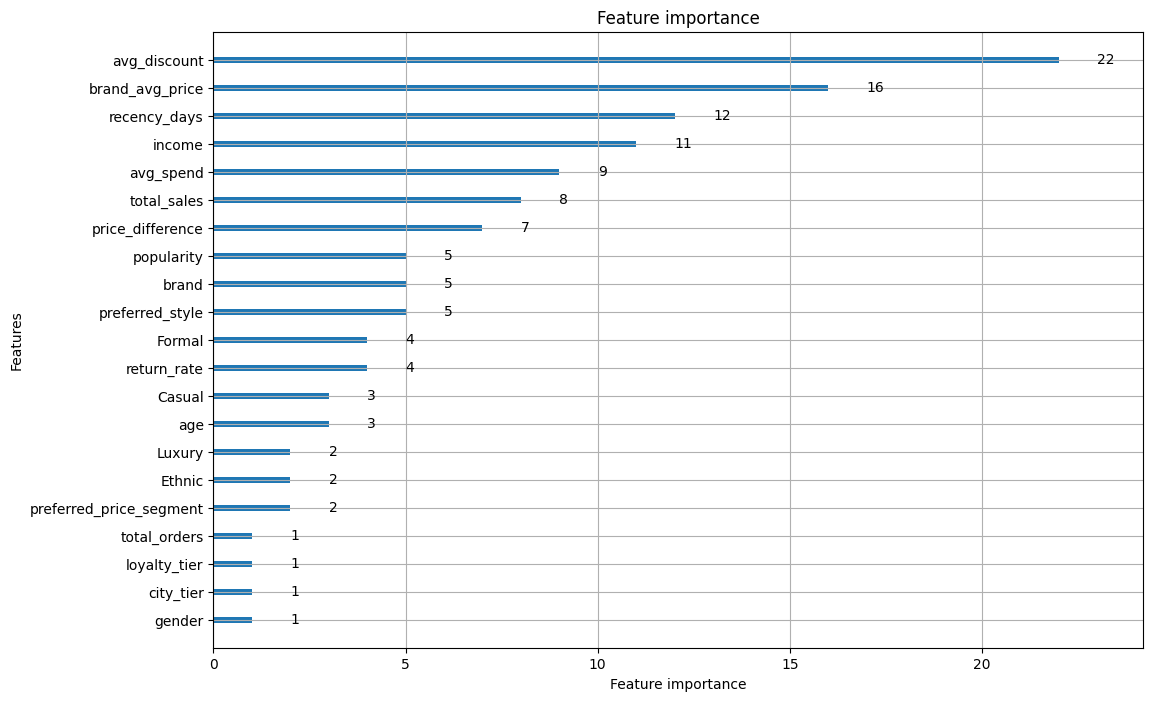

In [1713]:
plot_importance(ranker, figsize = (12,8))

# Predict

In [1714]:
X_test_copy = pd.concat([X_test, test_dev[["customer_id", "feature_cutoff_date"]], y_test], axis=1)
X_test_copy.shape

(221562, 35)

In [1715]:
# Score each snapshot individually
for cutoff in X_test_copy["feature_cutoff_date"].unique():
    print(cutoff.month_name())
    X_test_copy.loc[X_test_copy["feature_cutoff_date"] == cutoff, "score"] = ranker.predict(
        X_test_copy[X_test_copy["feature_cutoff_date"] == cutoff].drop(
            columns=["customer_id", "feature_cutoff_date", "label", "score"], 
            errors="ignore",
            axis=1))

March
June
September


In [2010]:
def get_top_n(df, n=3):
    top_brands = (
        df
        .sort_values(
            ["feature_cutoff_date","score"],
            ascending=[True,False]
        )
        .groupby(["customer_id", "feature_cutoff_date"])
        .head(3)
    )
    return top_brands[["customer_id", "feature_cutoff_date", "brand", "label", "score"]].sort_values(
        ["feature_cutoff_date","score"]
        ,ascending=[True,False]
        )

In [2011]:
top3_predictions = get_top_n(X_test_copy)
top3_predictions.shape

(83289, 5)

In [1718]:
top3_predictions[top3_predictions["customer_id"] == 100001]

,customer_id,feature_cutoff_date,brand,label,score
517054,100001,2025-03-31,Brand_B,0,0.043419
517055,100001,2025-03-31,Brand_C,0,0.032055
517057,100001,2025-03-31,Brand_E,0,0.026165
590956,100001,2025-06-30,Brand_B,0,0.032337
590961,100001,2025-06-30,Brand_H,0,0.024068
590962,100001,2025-06-30,Brand_I,0,0.024068
664680,100001,2025-09-30,Brand_B,0,0.032337
664685,100001,2025-09-30,Brand_H,0,0.024068
664686,100001,2025-09-30,Brand_I,0,0.024068


# Evaluation 

In [1719]:
from sklearn.metrics import ndcg_score

def ndcg_at_k(df, k=3):
    scores = []
    cust_ids = []
    for (cid, cutoff), grp in df.groupby(["customer_id", "feature_cutoff_date"]):
        if grp["label"].sum() == 0:
            cust_ids.append(cid)
            continue 

        grp = grp.sort_values("score", ascending=False)
        y_true = [grp["label"].values]
        y_score = [grp["score"].values]

        scores.append(
            ndcg_score(y_true, y_score, k=k)
        )
    print(f"Skipped Cust IDs from scoring = {len(cust_ids)}")
    return np.mean(scores)

In [1720]:
ndcg = ndcg_at_k(X_test_copy, k=3)
ndcg

Skipped Cust IDs from scoring = 16846


np.float64(0.2846252660541309)

In [1520]:
def recall_at_k(df, k=3):
    recalls = []
    cust_ids = []
    for (cid, cutoff), grp in df.groupby(["customer_id", "feature_cutoff_date"]):
        if grp["label"].sum() == 0:
            cust_ids.append(cid)
            continue 

        grp = grp.sort_values("score", ascending=False)

        topk = grp.head(k)
        positives = grp["label"].sum()
        if positives == 0:
            continue

        recall = (
            topk["label"].sum()
            /
            positives
        )
        recalls.append(recall)
    print(f"Skipped Cust IDs from scoring = {len(cust_ids)}")
    return np.mean(recalls)

In [ ]:
recall = recall_at_k(
    X_test_copy,
    k=3
)

recall

In [1519]:
def precision_at_k(df, k=3):
    precisions = []
    cust_ids = []
    for (cid, cutoff), grp in df.groupby(["customer_id", "feature_cutoff_date"]):
        if grp["label"].sum() == 0:
            cust_ids.append(cid)
            continue 

        grp = grp.sort_values(
            "score",
            ascending=False
        )

        topk = grp.head(k)

        precisions.append(
            topk["label"].sum()/k
        )
    print(f"Skipped Cust IDs from scoring = {len(cust_ids)}")
    return np.mean(precisions)

In [1518]:
def map_at_k(df, k=3):
    ap_scores = []
    cust_ids = []
    for (cid, cutoff), grp in df.groupby(["customer_id", "feature_cutoff_date"]):
        if grp["label"].sum() == 0:
            cust_ids.append(cid)
            continue 

        grp = grp.sort_values(
            "score",
            ascending=False
        )

        total_relevant = grp["label"].sum()
        topk = grp.head(k)

        hits = 0
        precision_sum = 0

        for rank, label in enumerate(topk["label"], start=1):
            if label == 1:
                hits += 1
                precision_sum += hits / rank

        ap = precision_sum / min(
            total_relevant,
            k
        )
        ap_scores.append(ap)
        
    print(f"Skipped Cust IDs from scoring = {len(cust_ids)}")
    return np.mean(ap_scores)

In [1517]:
def mrr(df):
    reciprocal_ranks = []
    cust_ids = []
    for (cid, cutoff), grp in df.groupby(["customer_id", "feature_cutoff_date"]):
        if grp["label"].sum() == 0:
            cust_ids.append(cid)
            continue 

        grp = grp.sort_values("score", ascending=False)
        labels = grp["label"].values

        rank = np.where(labels == 1)[0]

        if len(rank):
            reciprocal_ranks.append(
                1 / (rank[0] + 1)
            )
        else:
            reciprocal_ranks.append(0)

    print(f"Skipped Cust IDs from scoring = {len(cust_ids)}")
    return np.mean(
        reciprocal_ranks
    )

In [1516]:
def hit_rate_at_k(df, k=3):
    hits = []
    cust_ids = []
    for (cid, cutoff), grp in df.groupby(["customer_id", "feature_cutoff_date"]):
        if grp["label"].sum() == 0:
            cust_ids.append(cid)
            continue 

        grp = grp.sort_values("score", ascending=False)
        topk = grp.head(k)

        hit = (
            topk["label"].sum() > 0
        )
        hits.append(hit)
    print(f"Skipped Cust IDs from scoring = {len(cust_ids)}")
    return np.mean(hits)

In [2039]:
def coverage_at_k(df, k=3):
    topk = (
        df.sort_values("score", ascending=False)
          .groupby(["customer_id", "feature_cutoff_date"])
          .head(k)
    )

    unique_brands = topk["brand"].nunique()
    total_brands = df["brand"].nunique()

    return unique_brands / total_brands

In [2042]:
coverage = coverage_at_k(
    X_test_copy,
    k=3
)

coverage

1.0

In [1721]:
metrics = []
for cutoff, grp in X_test_copy.groupby("feature_cutoff_date"):
    ndcg = ndcg_at_k(grp, 3)
    recall = recall_at_k(grp, 3)
    precision = precision_at_k(grp, 3)
    mapk = map_at_k(grp, 3)
    hit_rate = hit_rate_at_k(grp, 3)
    mrr_ = mrr(grp)
    arr = [cutoff.month_name(), ndcg, recall, precision, mapk, hit_rate, mrr_ ]
    metrics.append(arr)

metrics

Skipped Cust IDs from scoring = 5591
Skipped Cust IDs from scoring = 5591
Skipped Cust IDs from scoring = 5591
Skipped Cust IDs from scoring = 5591
Skipped Cust IDs from scoring = 5591
Skipped Cust IDs from scoring = 5591
Skipped Cust IDs from scoring = 5662
Skipped Cust IDs from scoring = 5662
Skipped Cust IDs from scoring = 5662
Skipped Cust IDs from scoring = 5662
Skipped Cust IDs from scoring = 5662
Skipped Cust IDs from scoring = 5662
Skipped Cust IDs from scoring = 5593
Skipped Cust IDs from scoring = 5593
Skipped Cust IDs from scoring = 5593
Skipped Cust IDs from scoring = 5593
Skipped Cust IDs from scoring = 5593
Skipped Cust IDs from scoring = 5593


[['March',
  np.float64(0.2864244026371605),
  np.float64(0.3807216307216308),
  np.float64(0.1567021567021567),
  np.float64(0.2421360754694088),
  np.float64(0.44226044226044225),
  np.float64(0.38088748922082255)],
 ['June',
  np.float64(0.2844306667568573),
  np.float64(0.37679336687162285),
  np.float64(0.15585988447922489),
  np.float64(0.23743866840568909),
  np.float64(0.4354387926215763),
  np.float64(0.376591183333777)],
 ['September',
  np.float64(0.28302190342682065),
  np.float64(0.38155150525933984),
  np.float64(0.1558759521218716),
  np.float64(0.23750906782734857),
  np.float64(0.44532100108813927),
  np.float64(0.3772353273917474)]]

In [1722]:
pd.DataFrame(metrics, columns=["snapshot", "ndcg@k", "recall@k", "precision@k", "map@k", "hit_rate@k", "mrr"])

,snapshot,ndcg@k,recall@k,precision@k,map@k,hit_rate@k,mrr
0,March,0.286424,0.380722,0.156702,0.242136,0.442260,0.380887
1,June,0.284431,0.376793,0.155860,0.237439,0.435439,0.376591
2,September,0.283022,0.381552,0.155876,0.237509,0.445321,0.377235


# Save Model

In [2037]:
with open("cross_brand_ranker_dev.pkl", 'wb') as pkl:
    pickle.dump(ranker, pkl)

# MLFlow

In [1053]:
mlflow.tracking.get_tracking_uri()

'sqlite:///C:/git/ML-hands-on-notebooks/Recommendation%20Systems/mlflow.db'

In [1055]:
mlflow.set_tracking_uri(uri="http://localhost:8000")
mlflow.tracking.get_tracking_uri()

'http://localhost:8000'

In [1063]:
experiment_id = mlflow.create_experiment(name="Cross-brand Expansion")

#To record runs to this experiment
mlflow.set_experiment("Cross-brand Expansion")

<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1783318403510, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1783318403510, lifecycle_stage='active', name='Cross-brand Expansion', tags={}, trace_location=None, workspace='default'>

In [1064]:
mlflow.get_artifact_uri()

2026/07/06 11:43:29 WARNING mlflow.tracking.fluent: No active run found. A new active run will be created. If this is not intended, please create a run using `mlflow.start_run()` first.


'mlflow-artifacts:/1/62ad46efb9f043aebba50bfa72b621f1/artifacts'

In [1092]:
def track_model(k=5):
    with mlflow.start_run(run_name="Lgbm_with_6_snapshots", log_system_metrics=True) as run:
        mlflow.log_params(params)
        ranker = LGBMRanker(**params)
        ranker.fit(
            X_train,
            y_train,
            group=group,
            feature_name=X_train.columns.to_list(),
            categorical_feature=categorical_cols.to_list(),
            eval_set=[(X_val, y_val)],
            eval_group=[val_group],
            eval_metric="ndcg",
            callbacks=[
                early_stopping(stopping_rounds=10), # Stop if val metric doesn't improve for 10 rounds
                log_evaluation(period=1)            # Print metrics at every boosting round
            ]
        )

        for cutoff, grp in X_test_copy.groupby("feature_cutoff_date"):
            print(cutoff.month_name())
            X_test_copy.loc[X_test_copy["feature_cutoff_date"] == cutoff, "score"] = ranker.predict(
            X_test_copy[X_test_copy["feature_cutoff_date"] == cutoff].drop(
            columns=["customer_id", "feature_cutoff_date", "label", "score"], 
            errors="ignore",
            axis=1))

           # mlflow.log_metric("Snapshot", cutoff.month_name())
            ndcg = ndcg_at_k(grp, k)
            mlflow.log_metric(f"ndcg_{k}_{cutoff.month_name()}", ndcg)
            recall = recall_at_k(grp, k)
            mlflow.log_metric(f"recall_{k}_{cutoff.month_name()}", recall)
            mapk = map_at_k(grp, k)
            mlflow.log_metric(f"map_{k}_{cutoff.month_name()}", mapk)
            hit_rate = hit_rate_at_k(grp, k)
            mlflow.log_metric(f"hitrate_{k}_{cutoff.month_name()}", hit_rate)
            mrr_ = mrr(grp)
            mlflow.log_metric(f"mrr_{cutoff.month_name()}", mrr_)
           # mlflow.sklearn.log_model(ranker, "LGBM Ranker", skops_trusted_types=True)
            mlflow.end_run()

In [1093]:
track_model(k=5)

2026/07/06 20:20:10 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/07/06 20:20:10 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.099280 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1371
[LightGBM] [Info] Number of data points in the train set: 417375, number of used features: 18
[1]	valid_0's ndcg@1: 0.65051	valid_0's ndcg@2: 0.677289	valid_0's ndcg@3: 0.701935	valid_0's ndcg@4: 0.725091	valid_0's ndcg@5: 0.745727
Training until validation scores don't improve for 10 rounds
[2]	valid_0's ndcg@1: 0.652095	valid_0's ndcg@2: 0.679445	valid_0's ndcg@3: 0.706423	valid_0's ndcg@4: 0.728279	valid_0's ndcg@5: 0.74999
[3]	valid_0's ndcg@1: 0.650849	valid_0's ndcg@2: 0.675556	valid_0's ndcg@3: 0.701404	valid_0's ndcg@4: 0.726127	valid_0's ndcg@5: 0.747072
[4]	valid_0's ndcg@1: 0.64983	valid_0's ndcg@2: 0.676759	valid_0's ndcg@3: 0.703962	valid_0's ndcg@4: 0.727689	valid_0's ndcg@5: 0.747915
[5]	valid_0's ndcg@1: 0.652888	valid_0's ndcg@2: 0.679704	valid_0's ndcg@3: 0.704641	valid_0's n

2026/07/06 20:21:10 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/07/06 20:21:10 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!


🏃 View run Lgbm_with_6_snapshots at: http://localhost:8000/#/experiments/1/runs/e43ba7ae5a504830b58fe6ba1c4d810b
🧪 View experiment at: http://localhost:8000/#/experiments/1
June
🏃 View run honorable-hog-831 at: http://localhost:8000/#/experiments/1/runs/30c81726db6743048a5bc699c19d60c1
🧪 View experiment at: http://localhost:8000/#/experiments/1
September
🏃 View run abrasive-newt-374 at: http://localhost:8000/#/experiments/1/runs/dff20850f99d4d78be313a9f1afac437
🧪 View experiment at: http://localhost:8000/#/experiments/1


In [1095]:
mlflow.active_run()

In [1097]:
expr = mlflow.get_experiment_by_name("Cross-brand Expansion")
expr.experiment_id

'1'

In [1098]:
runs_df = mlflow.search_runs(experiment_ids=[expr.experiment_id])

In [1099]:
runs_df

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.ndcg_5_September,metrics.mrr_September,metrics.hitrate_5_September,metrics.recall_5_September,...,params.boosting_type,params.n_estimators,params.random_state,params.objective,params.num_leaves,params.learning_rate,tags.mlflow.user,tags.mlflow.runName,tags.mlflow.source.name,tags.mlflow.source.type
0,dff20850f99d4d78be313a9f1afac437,1,FINISHED,mlflow-artifacts:/1/dff20850f99d4d78be313a9f1a...,2026-07-06 14:52:31.375000+00:00,2026-07-06 14:53:24.429000+00:00,0.164711,0.156897,0.292525,0.640483,...,None,None,None,None,None,None,nedwi,abrasive-newt-374,C:\Users\nedwi\AppData\Local\Programs\Python\P...,NOTEBOOK
1,30c81726db6743048a5bc699c19d60c1,1,FINISHED,mlflow-artifacts:/1/30c81726db6743048a5bc699c1...,2026-07-06 14:51:25.234000+00:00,2026-07-06 14:52:12.809000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,None,None,None,nedwi,honorable-hog-831,C:\Users\nedwi\AppData\Local\Programs\Python\P...,NOTEBOOK
2,e43ba7ae5a504830b58fe6ba1c4d810b,1,FINISHED,mlflow-artifacts:/1/e43ba7ae5a504830b58fe6ba1c...,2026-07-06 14:50:07.821000+00:00,2026-07-06 14:51:10.077000+00:00,NaN,NaN,NaN,NaN,...,gbdt,300,42,lambdarank,63,0.05,nedwi,Lgbm_with_6_snapshots,C:\Users\nedwi\AppData\Local\Programs\Python\P...,NOTEBOOK
3,dfaf8b4d00ad418cbf3a2cd19660aed5,1,FAILED,mlflow-artifacts:/1/dfaf8b4d00ad418cbf3a2cd196...,2026-07-06 14:41:20.719000+00:00,2026-07-06 14:43:06.721000+00:00,NaN,NaN,NaN,NaN,...,gbdt,300,42,lambdarank,63,0.05,nedwi,Lgbm_with_6_snapshots,C:\Users\nedwi\AppData\Local\Programs\Python\P...,NOTEBOOK
4,7813d7725f914fffb3eadffce25461f3,1,FAILED,mlflow-artifacts:/1/7813d7725f914fffb3eadffce2...,2026-07-06 14:39:41.677000+00:00,2026-07-06 14:40:09.905000+00:00,NaN,NaN,NaN,NaN,...,gbdt,300,42,lambdarank,63,0.05,nedwi,Lgbm_with_6_snapshots,C:\Users\nedwi\AppData\Local\Programs\Python\P...,NOTEBOOK
5,ff32d51834ae49b68de28f0e33e18965,1,FAILED,mlflow-artifacts:/1/ff32d51834ae49b68de28f0e33...,2026-07-06 14:36:43.629000+00:00,2026-07-06 14:37:07.681000+00:00,NaN,NaN,NaN,NaN,...,gbdt,300,42,lambdarank,63,0.05,nedwi,Lgbm_with_6_snapshots,C:\Users\nedwi\AppData\Local\Programs\Python\P...,NOTEBOOK
6,62ad46efb9f043aebba50bfa72b621f1,1,FINISHED,mlflow-artifacts:/1/62ad46efb9f043aebba50bfa72...,2026-07-06 06:13:29.861000+00:00,2026-07-06 14:36:12.148000+00:00,NaN,NaN,NaN,NaN,...,None,None,None,None,None,None,nedwi,exultant-smelt-696,C:\Users\nedwi\AppData\Local\Programs\Python\P...,NOTEBOOK


In [ ]:
best_runs = runs_df.sort_values("metrics.rmse", ascending=True)


# Retrain model with all snapshots

In [1760]:
# rolling retrain for production

#1. reload all tables with latest data
#2. Build new snapshots up to the latest valid cutoff.
#3. calculate features, merge, cross-join, etc
#4 create labels, interaction features, etc
#5. train/test split  (current step)

latest_txn_date = transactions["transaction_date"].max()
label_window = pd.DateOffset(months=6)  #last 3 months for holdout

latest_train_cutoff = latest_txn_date - label_window
print(latest_train_cutoff)

train_prod = merged[
    merged["feature_cutoff_date"] <= latest_train_cutoff
]
holdout_prod = merged[
    merged["feature_cutoff_date"] > latest_train_cutoff
]

print(train_prod.shape)
print(holdout_prod.shape)

2025-06-30 00:00:00
(664680, 36)
(73936, 36)


In [1761]:
print(f"Production Training total cufoffs: {train_prod.feature_cutoff_date.nunique()}")
print(f"Production Holdout total cufoffs: {holdout_prod.feature_cutoff_date.nunique()}")

Production Training total cufoffs: 9
Production Holdout total cufoffs: 1


In [2046]:
train_prod.feature_cutoff_date.value_counts().sort_index()

feature_cutoff_date
2023-06-30    73633
2023-09-30    73456
2023-12-31    73754
2024-03-31    74018
2024-06-30    73900
2024-09-30    74088
2024-12-31    74205
2025-03-31    73902
2025-06-30    73724
Name: count, dtype: int64

In [1762]:
train_prod["label"].value_counts(normalize=True)

label
0    0.939419
1    0.060581
Name: proportion, dtype: float64

In [1763]:
# Filter single branded customer
train_prod_filtered = train_prod.groupby(
    ["customer_id", "feature_cutoff_date"]
).filter(
    lambda g: g["label"].sum() > 0
)

train_prod_filtered.shape

(266016, 36)

In [1764]:
train_prod_filtered.shape

(266016, 36)

In [1765]:
# Postivies distribution
train_prod_filtered.groupby(["customer_id", "feature_cutoff_date"])["label"].sum().value_counts(normalize=True) * 100

label
1    79.534813
2    17.906656
3     2.350421
4     0.205050
5     0.003060
Name: proportion, dtype: float64

In [1766]:
X_train_prod = train_prod_filtered[feature_cols]
print(X_train_prod.shape)
y_train_prod = train_prod_filtered["label"]
print(y_train_prod.shape)

X_holdout_prod = holdout_prod[feature_cols]
print(X_holdout_prod.shape)
y_holdout_prod = holdout_prod["label"]
print(y_holdout_prod.shape)

(266016, 32)
(266016,)
(73936, 32)
(73936,)


## Feature engg

In [1767]:

X_train_prod = age_cleanup(X_train_prod)
X_holdout_prod = age_cleanup(X_holdout_prod)

for col in categorical_cols:
    X_train_prod[col] = X_train_prod[col].astype("category")
    X_holdout_prod[col] = X_holdout_prod[col].astype("category")

cat_order = ["Budget", "Mid", "Premium", "Luxury"]
X_train_prod["price_segment"] = pd.Categorical(X_train_prod["price_segment"], categories=cat_order, ordered=True)
X_holdout_prod["price_segment"] = pd.Categorical(X_holdout_prod["price_segment"], categories=cat_order, ordered=True)

cat_order = ["Silver", "Gold", "Platinum"]
X_train_prod["loyalty_tier"] = pd.Categorical(X_train_prod["loyalty_tier"], categories=cat_order, ordered=True)
X_holdout_prod["loyalty_tier"] = pd.Categorical(X_holdout_prod["loyalty_tier"], categories=cat_order, ordered=True)

C:\Users\nedwi\AppData\Local\Temp\ipykernel_97724\4128297499.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["target_age_mean"] = df["target_age"].map(lambda x: np.mean([np.int32(x.split('-')[0]), np.int32(x.split('-')[1])]))
C:\Users\nedwi\AppData\Local\Temp\ipykernel_97724\4128297499.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["age_category"] = df.apply(categorize_age, axis=1)
C:\Users\nedwi\AppData\Local\Temp\ipykernel_97724\4128297499.py:5: SettingWithCopyWarning: 
A value is trying to

age_category
Middle Aged     79884
Adults          79816
Older           53348
Young Adults    52968
Name: count, dtype: int64
(266016, 32)


C:\Users\nedwi\AppData\Local\Temp\ipykernel_97724\4128297499.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["target_age_mean"] = df["target_age"].map(lambda x: np.mean([np.int32(x.split('-')[0]), np.int32(x.split('-')[1])]))
C:\Users\nedwi\AppData\Local\Temp\ipykernel_97724\4128297499.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["age_category"] = df.apply(categorize_age, axis=1)
C:\Users\nedwi\AppData\Local\Temp\ipykernel_97724\4128297499.py:5: SettingWithCopyWarning: 
A value is trying to

age_category
Middle Aged     22195
Adults          22192
Older           14810
Young Adults    14739
Name: count, dtype: int64
(73936, 32)


C:\Users\nedwi\AppData\Local\Temp\ipykernel_97724\1045985257.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train_prod[col] = X_train_prod[col].astype("category")
C:\Users\nedwi\AppData\Local\Temp\ipykernel_97724\1045985257.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_holdout_prod[col] = X_holdout_prod[col].astype("category")
C:\Users\nedwi\AppData\Local\Temp\ipykernel_97724\1045985257.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using

In [1768]:
X_train_prod.info()

<class 'pandas.core.frame.DataFrame'>
Index: 266016 entries, 15 to 664670
Data columns (total 32 columns):
 #   Column                   Non-Null Count   Dtype   
---  ------                   --------------   -----   
 0   age                      266016 non-null  int64   
 1   gender                   266016 non-null  category
 2   income                   266016 non-null  int64   
 3   city_tier                266016 non-null  int64   
 4   loyalty_tier             266016 non-null  category
 5   total_orders             266016 non-null  int64   
 6   total_sales              266016 non-null  int64   
 7   avg_spend                266016 non-null  float64 
 8   avg_discount             266016 non-null  float64 
 9   return_rate              266016 non-null  float64 
 10  num_brands               266016 non-null  int64   
 11  brand_avg_price          266016 non-null  float64 
 12  preferred_price_segment  266016 non-null  category
 13  preferred_style          266016 non-null  catego

## Retrain Model

In [1769]:

group_prod = (
    train_prod_filtered
    .groupby(["customer_id", "feature_cutoff_date"], sort=False)
    .size()
    .values
)

print(len(group_prod))
print(np.take(group_prod, range(0, 10)))

32675
[8 8 9 7 6 7 9 9 8 9]


In [1770]:
ranker_prod = LGBMRanker(
    objective="lambdarank",
    boosting_type="gbdt",
    metric="ndcg",
    learning_rate=0.05,
    num_leaves=63,
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

ranker_prod.fit(
    X_train_prod,
    y_train_prod,
    group=group_prod,
    feature_name=X_train_prod.columns.to_list(),
    categorical_feature=categorical_cols.to_list(),
    #eval_set=[(X_val, y_val)],
    #eval_group=[val_group],
    #eval_metric="ndcg",
    # callbacks=[
    #     early_stopping(stopping_rounds=300), # Stop if val metric doesn't improve for 10 rounds
    #     log_evaluation(period=1)            # Print metrics at every boosting round
    #]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.027563 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2080
[LightGBM] [Info] Number of data points in the train set: 266016, number of used features: 32


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,'lambdarank'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


<Axes: title={'center': 'Feature importance'}, xlabel='Feature importance', ylabel='Features'>

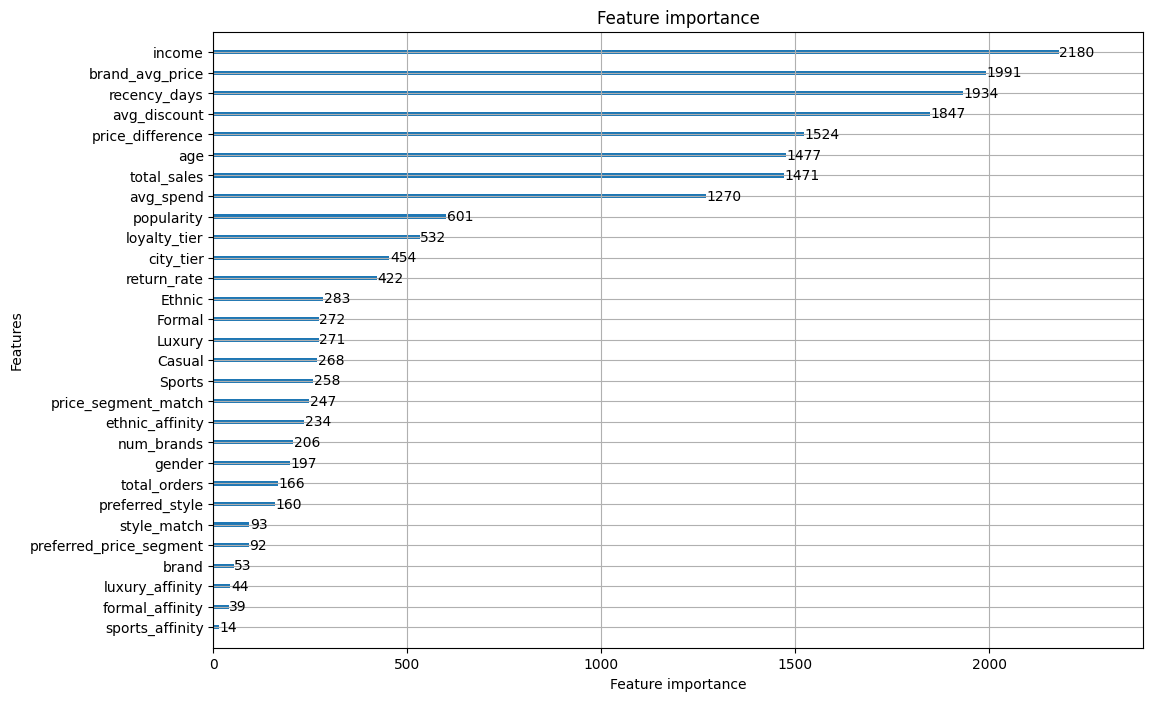

In [1771]:
plot_importance(ranker_prod, figsize = (12,8))

In [1772]:
train_prod_filtered.feature_cutoff_date.value_counts().sort_index(ascending=True)

feature_cutoff_date
2023-06-30    29268
2023-09-30    29150
2023-12-31    29402
2024-03-31    29687
2024-06-30    29600
2024-09-30    30367
2024-12-31    29560
2025-03-31    29836
2025-06-30    29146
Name: count, dtype: int64

## Score & Evaluate holdout snapshot

In [1774]:
#Predict holdout
X_holdout_copy = pd.concat([X_holdout_prod, holdout_prod[["customer_id", "feature_cutoff_date"]], y_holdout_prod], axis=1)
X_holdout_copy.shape

(73936, 35)

In [1775]:
X_holdout_copy.feature_cutoff_date.value_counts()

feature_cutoff_date
2025-09-30    73936
Name: count, dtype: int64

In [1776]:

for cutoff in X_holdout_copy["feature_cutoff_date"].unique():
    print(cutoff.month_name())
    X_holdout_copy.loc[X_holdout_copy["feature_cutoff_date"] == cutoff, "score"] = ranker_prod.predict(
        X_holdout_copy[X_holdout_copy["feature_cutoff_date"] == cutoff].drop(
            columns=["customer_id", "feature_cutoff_date", "label", "score"], 
            errors="ignore",
            axis=1))

X_holdout_copy.shape

September


(73936, 36)

In [1778]:
metrics = []
for cutoff, grp in X_holdout_copy.groupby("feature_cutoff_date"):
    ndcg = ndcg_at_k(grp, 3)
    recall = recall_at_k(grp, 3)
    precision = precision_at_k(grp, 3)
    mapk = map_at_k(grp, 3)
    hit_rate = hit_rate_at_k(grp, 3)
    mrr_ = mrr(grp)
    arr = [cutoff.month_name(), ndcg, recall, precision, mapk, hit_rate, mrr_ ]
    metrics.append(arr)


pd.DataFrame(metrics, columns=["snapshot", "ndcg@k", "recall@k", "precision@k", "map@k", "hit_rate@k", "mrr"])

Skipped Cust IDs from scoring = 5593
Skipped Cust IDs from scoring = 5593
Skipped Cust IDs from scoring = 5593
Skipped Cust IDs from scoring = 5593
Skipped Cust IDs from scoring = 5593
Skipped Cust IDs from scoring = 5593


,snapshot,ndcg@k,recall@k,precision@k,map@k,hit_rate@k,mrr
0,September,0.287581,0.382368,0.156148,0.241597,0.441513,0.380847


## Save New model

In [1779]:

with open("cross_brand_ranker_prod.pkl", 'wb') as pkl:
    pickle.dump(ranker_prod, pkl)

In [1750]:
with open('cross_brand_ranker_prod.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

In [1751]:
loaded_model

,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.05
,n_estimators,300
,subsample_for_bin,200000
,objective,'lambdarank'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


Before promoting the retrained model, 
1. compare it against the current production model on a recent validation period
2. monitor online business KPIs using champion/challenger deployment).

Only if the new model is at least as good (or better) and passes business checks, retrain it one final time on all available snapshots, including the validation period.

# Scoring
| Score Date  | Feature Window |
| ----------- | -------------- |
| 31-Dec-2025 | Jul – Dec 2025 |

The model predicts:

    Which brand will this customer adopt during Jan–Mar 2026?

Feature window:

    This defines: How much history is used to compute features. Eg. last 6 months

Population:

    This defines: Which customers should receive predictions.
    Eg. Customers satisfying:
        Last purchase ≤ 12 months
        Not opted out
        At least one owned brand
        At least one candidate brand remaining

## define scoring window and feature window 

In [1895]:
score_date = pd.Timestamp("2025-12-31")
feature_start = score_date - pd.DateOffset(months=6)
print(f"feature_window = {feature_start} to {score_date}")

feature_window = 2025-06-30 00:00:00 to 2025-12-31 00:00:00


## define scoring population

In [1896]:
last_purchase = (
    transactions
    .groupby("customer_id")["transaction_date"]
    .max()
    .reset_index(name="last_purchase_date")
)

brands_owned = (
    transactions
    .groupby("customer_id")["brand"]
    .nunique()
    .reset_index(name="brands_owned")
)

orders = (
    transactions
    .groupby("customer_id")
    .size()
    .reset_index(name="historical_orders")
)

In [1897]:
population = (
    demo_df
    .merge(last_purchase, on="customer_id", how="left")
    .merge(brands_owned, on="customer_id", how="left")
    .merge(orders, on="customer_id", how="left")
)

population["brands_owned"] = population["brands_owned"].fillna(0)
population["historical_orders"] = population["historical_orders"].fillna(0)

In [1898]:
TOTAL_BRANDS = brand_df["brand"].nunique()

population["candidate_brand_count"] = (
    TOTAL_BRANDS
    - population["brands_owned"]
)

population["days_since_last_purchase"] = (
    score_date
    - population["last_purchase_date"]
).dt.days

population


,customer_id,age,gender,income,city_tier,loyalty_tier,last_purchase_date,brands_owned,historical_orders,candidate_brand_count,days_since_last_purchase
0,100001,37,F,160034,1,Platinum,2025-08-04,5,15,5,149
1,100002,34,F,188319,1,Platinum,2025-12-26,5,24,5,5
2,100003,41,M,80124,2,Platinum,2024-09-11,5,13,5,476
3,100004,55,F,117707,3,Platinum,2025-08-21,5,12,5,132
4,100005,51,F,58606,3,Gold,2025-12-03,6,25,4,28
...,...,...,...,...,...,...,...,...,...,...,...
9995,109996,32,F,25418,3,Gold,2025-10-21,5,19,5,71
9996,109997,52,M,166173,1,Gold,2025-06-17,5,15,5,197
9997,109998,51,F,207825,3,Gold,2025-10-11,6,20,4,81
9998,109999,46,M,212420,3,Silver,2025-12-22,5,16,5,9


In [1899]:
population.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   customer_id               10000 non-null  int64         
 1   age                       10000 non-null  int64         
 2   gender                    10000 non-null  object        
 3   income                    10000 non-null  int64         
 4   city_tier                 10000 non-null  int64         
 5   loyalty_tier              10000 non-null  object        
 6   last_purchase_date        10000 non-null  datetime64[ns]
 7   brands_owned              10000 non-null  int64         
 8   historical_orders         10000 non-null  int64         
 9   candidate_brand_count     10000 non-null  int64         
 10  days_since_last_purchase  10000 non-null  int64         
dtypes: datetime64[ns](1), int64(8), object(2)
memory usage: 859.5+ KB


## Business rule to select population

In [1901]:
score_population = population.loc[
    (
        population["days_since_last_purchase"] <= 365
    )
    # &
    # (
    #     population["opt_out"] == 0
    # )
    &
    (
        population["historical_orders"] > 0
    )
    &
    (
        population["candidate_brand_count"] > 0
    )
]

score_population.shape

(9936, 11)

## snapshot feature calculation --- same as training

In [1929]:
scoring_snapshot = create_customer_features(transactions, score_population, score_date, merge_with_customers="left")
scoring_snapshot.shape

Feature window = (Timestamp('2025-06-30 00:00:00'), Timestamp('2025-12-31 00:00:00'))
left


(9936, 28)

In [1930]:
scoring_snapshot

,customer_id,age,gender,income,city_tier,loyalty_tier,last_purchase_date,brands_owned,historical_orders,candidate_brand_count,...,brand_avg_price,preferred_price_segment,preferred_style,recency_days,feature_cutoff_date,Casual,Ethnic,Formal,Luxury,Sports
0,100001,37,F,160034,1,Platinum,2025-08-04,5,15,5,...,6264.331276,Budget,Casual,149.0,2025-12-31,0.000000,0.000000,0.500000,0.000000,0.500000
1,100002,34,F,188319,1,Platinum,2025-12-26,5,24,5,...,6294.599238,Premium,Ethnic,5.0,2025-12-31,0.428571,0.000000,0.142857,0.000000,0.428571
2,100004,55,F,117707,3,Platinum,2025-08-21,5,12,5,...,6339.872826,Budget,Formal,132.0,2025-12-31,0.000000,0.000000,0.000000,0.000000,1.000000
3,100005,51,F,58606,3,Gold,2025-12-03,6,25,4,...,6272.153070,Budget,Sports,28.0,2025-12-31,0.000000,0.000000,0.857143,0.000000,0.142857
4,100006,30,F,65907,1,Gold,2025-09-17,3,16,7,...,6227.212654,Mid,Casual,105.0,2025-12-31,0.000000,0.000000,1.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9931,109996,32,F,25418,3,Gold,2025-10-21,5,19,5,...,6273.579042,Premium,Casual,71.0,2025-12-31,0.666667,0.000000,0.333333,0.000000,0.000000
9932,109997,52,M,166173,1,Gold,2025-06-17,5,15,5,...,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN
9933,109998,51,F,207825,3,Gold,2025-10-11,6,20,4,...,6283.499981,Premium,Casual,81.0,2025-12-31,0.333333,0.000000,0.333333,0.333333,0.000000
9934,109999,46,M,212420,3,Silver,2025-12-22,5,16,5,...,6276.743366,Premium,Ethnic,9.0,2025-12-31,0.000000,0.333333,0.000000,0.333333,0.333333


In [1931]:
scoring_snapshot.isnull().sum()

customer_id                   0
age                           0
gender                        0
income                        0
city_tier                     0
loyalty_tier                  0
last_purchase_date            0
brands_owned                  0
historical_orders             0
candidate_brand_count         0
days_since_last_purchase      0
total_orders                656
total_sales                 656
avg_spend                   656
avg_discount                656
return_rate                 656
last_purchase               656
num_brands                  656
brand_avg_price             656
preferred_price_segment     656
preferred_style             656
recency_days                656
feature_cutoff_date         656
Casual                      656
Ethnic                      656
Formal                      656
Luxury                      656
Sports                      656
dtype: int64

In [1937]:
#customers inactive in the last 6 months still remain in the scoring population, so their recent activity features are marked 0 
scoring_snapshot["total_orders"] = scoring_snapshot["total_orders"].fillna(0)
scoring_snapshot["total_sales"] = scoring_snapshot["total_sales"].fillna(0)
scoring_snapshot["avg_spend"] = scoring_snapshot["avg_spend"].fillna(0)
scoring_snapshot["avg_discount"] = scoring_snapshot["avg_discount"].fillna(0)
scoring_snapshot["return_rate"] = scoring_snapshot["return_rate"].fillna(0)
scoring_snapshot["num_brands"] = scoring_snapshot["num_brands"].fillna(0)
scoring_snapshot["brand_avg_price"] = scoring_snapshot["brand_avg_price"].fillna(0)

scoring_snapshot["Casual"] = scoring_snapshot["Casual"].fillna(0)
scoring_snapshot["Ethnic"] = scoring_snapshot["Ethnic"].fillna(0)
scoring_snapshot["Formal"] = scoring_snapshot["Formal"].fillna(0)
scoring_snapshot["Luxury"] = scoring_snapshot["Luxury"].fillna(0)
scoring_snapshot["Sports"] = scoring_snapshot["Sports"].fillna(0)


scoring_snapshot["recency_days"] = scoring_snapshot["days_since_last_purchase"] #updating recency from overall last purchase calculation to replace nulls

In [1938]:
scoring_snapshot.isnull().sum()

customer_id                   0
age                           0
gender                        0
income                        0
city_tier                     0
loyalty_tier                  0
last_purchase_date            0
brands_owned                  0
historical_orders             0
candidate_brand_count         0
days_since_last_purchase      0
total_orders                  0
total_sales                   0
avg_spend                     0
avg_discount                  0
return_rate                   0
last_purchase               656
num_brands                    0
brand_avg_price               0
preferred_price_segment     656
preferred_style             656
recency_days                  0
feature_cutoff_date         656
Casual                        0
Ethnic                        0
Formal                        0
Luxury                        0
Sports                        0
dtype: int64

## cross join with candidate brands

In [1964]:
scoring_candidate_df  = scoring_snapshot.merge(
    brand_df,
    how="cross"
)


scoring_candidate_df.shape

(99360, 33)

In [1952]:
scoring_candidate_df[scoring_candidate_df["customer_id"] == 100001]

,customer_id,age,gender,income,city_tier,loyalty_tier,last_purchase_date,brands_owned,historical_orders,candidate_brand_count,...,Casual,Ethnic,Formal,Luxury,Sports,brand,price_segment,style,target_age,popularity
0,100001,37,F,160034,1,Platinum,2025-08-04,5,15,5,...,0.0,0.0,0.5,0.0,0.5,Brand_A,Budget,Casual,18-25,0.72
1,100001,37,F,160034,1,Platinum,2025-08-04,5,15,5,...,0.0,0.0,0.5,0.0,0.5,Brand_B,Premium,Formal,30-45,0.84
2,100001,37,F,160034,1,Platinum,2025-08-04,5,15,5,...,0.0,0.0,0.5,0.0,0.5,Brand_C,Mid,Sports,20-35,0.66
3,100001,37,F,160034,1,Platinum,2025-08-04,5,15,5,...,0.0,0.0,0.5,0.0,0.5,Brand_D,Premium,Ethnic,25-40,0.81
4,100001,37,F,160034,1,Platinum,2025-08-04,5,15,5,...,0.0,0.0,0.5,0.0,0.5,Brand_E,Budget,Sports,18-30,0.58
5,100001,37,F,160034,1,Platinum,2025-08-04,5,15,5,...,0.0,0.0,0.5,0.0,0.5,Brand_F,Mid,Casual,25-35,0.63
6,100001,37,F,160034,1,Platinum,2025-08-04,5,15,5,...,0.0,0.0,0.5,0.0,0.5,Brand_G,Luxury,Luxury,30-50,0.79
7,100001,37,F,160034,1,Platinum,2025-08-04,5,15,5,...,0.0,0.0,0.5,0.0,0.5,Brand_H,Mid,Ethnic,25-45,0.68
8,100001,37,F,160034,1,Platinum,2025-08-04,5,15,5,...,0.0,0.0,0.5,0.0,0.5,Brand_I,Budget,Formal,25-40,0.55
9,100001,37,F,160034,1,Platinum,2025-08-04,5,15,5,...,0.0,0.0,0.5,0.0,0.5,Brand_J,Premium,Casual,20-35,0.74


## remove already purchased brands

In [1965]:
owned = transactions[
    ["customer_id","brand"]
].drop_duplicates()

scoring_candidate_df = (
    scoring_candidate_df
    .merge(
        owned.assign(already_owned=1),
        on=["customer_id","brand"],
        how="left"
    )
)

scoring_candidate_df = scoring_candidate_df.loc[
    scoring_candidate_df["already_owned"].isna()
]

scoring_candidate_df = scoring_candidate_df.drop(
    columns="already_owned"
)

scoring_candidate_df.shape

(60434, 33)

## Add Interaction features

In [1966]:
#Interaction Feature 1 — Price Gap
scoring_candidate_df["price_difference"] = (
    scoring_candidate_df["avg_spend"]
    -
    scoring_candidate_df["brand_avg_price"]
).abs()


#Interaction Feature 2 — Preferred Price Segment Match
scoring_candidate_df["price_segment_match"] = (
    scoring_candidate_df["preferred_price_segment"]
    ==
    scoring_candidate_df["price_segment"]
).astype(int)


#Interaction Feature 3 — Preferred Style Match
scoring_candidate_df["style_match"] = (
    scoring_candidate_df["preferred_style"]
    ==
    scoring_candidate_df["style"]
).astype(int)



scoring_candidate_df["sports_affinity"] = (
    scoring_candidate_df["Sports"] *
    (scoring_candidate_df["style"] == "Sports").astype(int)
)

scoring_candidate_df["formal_affinity"] = (
    scoring_candidate_df["Formal"] *
    (scoring_candidate_df["style"] == "Formal").astype(int)
)

scoring_candidate_df["ethnic_affinity"] = (
    scoring_candidate_df["Ethnic"] *
    (scoring_candidate_df["style"] == "Ethnic").astype(int)
)

scoring_candidate_df["luxury_affinity"] = (
    scoring_candidate_df["Luxury"] *
    (scoring_candidate_df["style"] == "Luxury").astype(int)
)

scoring_candidate_df.shape

(60434, 40)

## Feature engg

In [1967]:
scoring_df = scoring_candidate_df[feature_cols]
print(scoring_df.shape)

(60434, 32)


In [1968]:
scoring_df.isnull().sum()

age                           0
gender                        0
income                        0
city_tier                     0
loyalty_tier                  0
total_orders                  0
total_sales                   0
avg_spend                     0
avg_discount                  0
return_rate                   0
num_brands                    0
brand_avg_price               0
preferred_price_segment    4329
preferred_style            4329
recency_days                  0
Casual                        0
Ethnic                        0
Formal                        0
Luxury                        0
Sports                        0
brand                         0
price_segment                 0
style                         0
target_age                    0
popularity                    0
price_difference              0
price_segment_match           0
style_match                   0
sports_affinity               0
formal_affinity               0
ethnic_affinity               0
luxury_a

In [1969]:
scoring_df = age_cleanup(scoring_df)

for col in categorical_cols:
    scoring_df[col] = scoring_df[col].astype("category")


scoring_df["loyalty_tier"] = pd.Categorical(scoring_df["loyalty_tier"], categories=price_cat_order, ordered=True)
scoring_df["price_segment"] = pd.Categorical(scoring_df["price_segment"], categories=loyalty_cat_order, ordered=True)

scoring_df.info()

C:\Users\nedwi\AppData\Local\Temp\ipykernel_97724\4128297499.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["target_age_mean"] = df["target_age"].map(lambda x: np.mean([np.int32(x.split('-')[0]), np.int32(x.split('-')[1])]))


age_category
Adults          18195
Middle Aged     18126
Older           12145
Young Adults    11968
Name: count, dtype: int64
(60434, 32)
<class 'pandas.core.frame.DataFrame'>
Index: 60434 entries, 1 to 99359
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   age                      60434 non-null  int64   
 1   gender                   60434 non-null  category
 2   income                   60434 non-null  int64   
 3   city_tier                60434 non-null  int64   
 4   loyalty_tier             0 non-null      category
 5   total_orders             60434 non-null  float64 
 6   total_sales              60434 non-null  float64 
 7   avg_spend                60434 non-null  float64 
 8   avg_discount             60434 non-null  float64 
 9   return_rate              60434 non-null  float64 
 10  num_brands               60434 non-null  float64 
 11  brand_avg_price          60434 non-nu

C:\Users\nedwi\AppData\Local\Temp\ipykernel_97724\4128297499.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["age_category"] = df.apply(categorize_age, axis=1)
C:\Users\nedwi\AppData\Local\Temp\ipykernel_97724\4128297499.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["age_category"] = pd.Categorical(df["age_category"], categories=cat_order, ordered=True)
C:\Users\nedwi\AppData\Local\Temp\ipykernel_97724\4128297499.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice

## Predict

In [2032]:
score = ranker_prod.predict(scoring_df)
score

array([ 0.10221802,  0.03008374,  0.00294031, ...,  0.00800274,
       -0.0223545 ,  0.03974159], shape=(60434,))

In [2033]:
scores =  pd.concat([scoring_candidate_df.reset_index(drop=True), pd.Series(score, name="score")], axis=1)
scores.shape

(60434, 41)

In [2034]:
scores["customer_id"].nunique() * 3

29808

In [2035]:
def get_top_n_scoring(df, n=3):
    top_brands = (
        df
        .sort_values(
           "score",
            ascending=False
        )
        .groupby("customer_id")
        .head(3)
    )
    return top_brands[["customer_id", "brand", "score"]].sort_values(
        ["customer_id", "score"]
        ,ascending=[True,False]
    )
    
top3_predictions = get_top_n_scoring(scores, 3)
top3_predictions.shape

(29629, 3)

In [2036]:
top3_predictions

,customer_id,brand,score
0,100001,Brand_B,0.102218
1,100001,Brand_D,0.030084
2,100001,Brand_H,0.002940
5,100002,Brand_A,0.004057
6,100002,Brand_B,-0.001137
...,...,...,...
60421,109999,Brand_A,0.017740
60423,109999,Brand_C,-0.000555
60426,110000,Brand_A,0.047803
60428,110000,Brand_D,0.047037


# Pending

In [ ]:
# model evaluation  - done
# understand evaluation - done 
# improve metrics - done
# add mlflow  - done
# retrain for prod - done
# scoring - done
# customer filters for scoring - done
# business metrics
# hyperparam tuning